# US Flight Delay Predictor  —  2018 to 2022
### Big Data Project  |  AIE College

| Item | Detail |
|------|--------|
| Dataset | BTS On-Time Performance (Kaggle) — Combined_Flights_YYYY.parquet |
| Engine | Apache Spark via PySpark (local mode) |
| Regression models | Linear Regression, Decision Tree, Random Forest, GBT |
| Classification models | Logistic Regression, Random Forest Classifier, GBT Classifier |
| Cross-validation | 3-fold CV on the winning regression model |
| Visualisations | 15 charts — EDA, cleaning QA, seasonality, model results |
| Target | `ArrDelay` — arrival delay in minutes |

---

## Section 1 — Imports

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, count, when, stddev,
    round as spark_round,
    min as spark_min, max as spark_max,
    percentile_approx, concat_ws,
    abs as spark_abs,
)
from pyspark.sql.types import DoubleType, IntegerType, StringType

# Regression
from pyspark.ml.regression import (
    LinearRegression, DecisionTreeRegressor,
    RandomForestRegressor, GBTRegressor,
)
# Classification
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
)
# ML utilities
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import (
    RegressionEvaluator,
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import os, glob, time, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
PAL = ['#1565C0','#C62828','#2E7D32','#E65100','#6A1B9A','#00695C','#4E342E']

Imports OK


---
## Section 2 — SparkSession

In [2]:
os.makedirs('C:/tmp/spark-temp', exist_ok=True)

import sys
os.environ['PYSPARK_PYTHON']        = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

spark = (
    SparkSession.builder
    .appName('US Flight Delay Predictor')
    .master('local[*]')
    .config('spark.driver.memory',                           '20g')
    .config('spark.driver.maxResultSize',                    '6g')
    .config('spark.sql.shuffle.partitions',                  str(os.cpu_count() * 2))
    .config('spark.default.parallelism',                     str(os.cpu_count() * 2))
    .config('spark.sql.adaptive.enabled',                    'true')
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')
    .config('spark.sql.inMemoryColumnarStorage.compressed',  'true')
    .config('spark.serializer', 'org.apache.spark.serializer.KryoSerializer')
    .config('spark.pyspark.python',        sys.executable)   # <-- add this
    .config('spark.pyspark.driver.python', sys.executable)   # <-- add this
    .config('spark.local.dir', 'C:/tmp/spark-temp')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')
print(f'Spark {spark.version}')
print(f'Cores in use : {spark.sparkContext.defaultParallelism}')
spark

Spark 4.1.1
Cores in use : 32


---
## Section 3 — Load Data

**Why Parquet and not CSV?**
Parquet is a columnar binary format. Spark reads only the columns it needs
instead of scanning every byte of every row. For this dataset that means
reads in seconds instead of minutes, and roughly 5x less data to deserialise.

Folder structure expected:
```
data/
    Combined_Flights_2018.parquet
    Combined_Flights_2019.parquet
    Combined_Flights_2020.parquet
    Combined_Flights_2021.parquet
    Combined_Flights_2022.parquet
    Airlines.csv
```

In [ ]:
DATA_FOLDER  = r'C:\Users\outis\Desktop\College\Lvl 300\2nd term\Big Data\Project\Us flight delay'
AIRLINES_CSV = os.path.join(DATA_FOLDER, 'Airlines.csv')

parquet_files = sorted(glob.glob(os.path.join(DATA_FOLDER, 'Combined_Flights_*.parquet')))

if not parquet_files:
    raise FileNotFoundError('No Combined_Flights_*.parquet files found — check DATA_FOLDER')

print(f'Found {len(parquet_files)} parquet file(s):')
total_bytes = 0
for f in parquet_files:
    sz = os.path.getsize(f)
    total_bytes += sz
    print(f'  {os.path.basename(f):<40}  {sz/1e6:>8.1f} MB')
print(f'  Total : {total_bytes/1e9:.2f} GB')
print(f'Airlines CSV exists : {os.path.exists(AIRLINES_CSV)}')

Found 5 parquet file(s):
  Combined_Flights_2018.parquet                225.8 MB
  Combined_Flights_2019.parquet                308.7 MB
  Combined_Flights_2020.parquet                183.1 MB
  Combined_Flights_2021.parquet                243.0 MB
  Combined_Flights_2022.parquet                149.6 MB
  Total : 1.11 GB
Airlines CSV exists : True


In [4]:
# Read all parquet files — schema is embedded, no inferSchema needed
t0     = time.time()
df_raw = spark.read.parquet(*parquet_files)
df_raw = df_raw.drop('__index_level_0__')   # leftover pandas index
print(f'Read time  : {time.time()-t0:.1f}s')
print(f'Columns    : {len(df_raw.columns)}')
print(f'Partitions : {df_raw.rdd.getNumPartitions()}')
df_raw.printSchema()

Read time  : 1.4s
Columns    : 61
Partitions : 33
root
 |-- FlightDate: timestamp_ntz (nullable = true)
 |-- Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Cancelled: boolean (nullable = true)
 |-- Diverted: boolean (nullable = true)
 |-- CRSDepTime: long (nullable = true)
 |-- DepTime: double (nullable = true)
 |-- DepDelayMinutes: double (nullable = true)
 |-- DepDelay: double (nullable = true)
 |-- ArrTime: double (nullable = true)
 |-- ArrDelayMinutes: double (nullable = true)
 |-- AirTime: double (nullable = true)
 |-- CRSElapsedTime: double (nullable = true)
 |-- ActualElapsedTime: double (nullable = true)
 |-- Distance: double (nullable = true)
 |-- Year: long (nullable = true)
 |-- Quarter: long (nullable = true)
 |-- Month: long (nullable = true)
 |-- DayofMonth: long (nullable = true)
 |-- DayOfWeek: long (nullable = true)
 |-- Marketing_Airline_Network: string (nullable = true)
 |-- Operated_or_Branded_Code_Sh

In [5]:
# Load airline code -> full name mapping
airlines_pd  = pd.read_csv(AIRLINES_CSV)
airlines_pd.columns = [c.strip().lower() for c in airlines_pd.columns]

# Detect column names (Kaggle file uses 'Code' and 'Description')
code_col = [c for c in airlines_pd.columns if 'code' in c][0]
name_col = [c for c in airlines_pd.columns if 'description' in c or 'name' in c][0]
airlines_pd = airlines_pd.rename(columns={code_col: 'airline_code', name_col: 'airline_name'})
airlines_pd = airlines_pd[['airline_code','airline_name']].dropna()
airlines_pd['airline_code'] = airlines_pd['airline_code'].str.strip()
airlines_pd['airline_name'] = airlines_pd['airline_name'].str.strip()

airlines_spark = spark.createDataFrame(airlines_pd)
print(f'Airline mapping loaded : {len(airlines_pd)} entries')
airlines_pd.head(8)

Airline mapping loaded : 1570 entries


,airline_code,airline_name
0,02Q,Titan Airways
1,04Q,Tradewind Aviation
2,05Q,"Comlux Aviation, AG"
3,06Q,Master Top Linhas Aereas Ltd.
4,07Q,Flair Airlines Ltd.
5,09Q,"Swift Air, LLC"
6,0BQ,DCA
7,0CQ,ACM AIR CHARTER GmbH


---
## Section 4 — Data Cleaning

Steps performed in order:

| # | Step |
|---|------|
| 1 | Select and cast only the columns needed |
| 2 | Remove cancelled and diverted flights |
| 3 | Drop rows where the label (ArrDelay) is null |
| 4 | Report missing values — single aggregation pass |
| 5 | Fill remaining nulls |
| 6 | Remove outliers using IQR x 3 |
| 7 | Remove duplicate rows |
| 8 | Validate year range and distance |
| 9 | Engineer new features |
| 10 | Join airline full names |
| 11 | Cache the clean DataFrame |

In [ ]:
#Select and cast

required = {
    'Airline':                      ('airline',       'string'),
    'IATA_Code_Marketing_Airline':  ('airline_code',  'string'),
    'Origin':                       ('origin',        'string'),
    'Dest':                         ('dest',          'string'),
    'Cancelled':                    ('cancelled',     None),        # Boolean, no cast
    'Diverted':                     ('diverted',      None),        # Boolean, no cast
    'ArrDelay':                     ('arr_delay',     DoubleType()),
    'DepDelay':                     ('dep_delay',     DoubleType()),
    'Distance':                     ('distance',      DoubleType()),
    'CRSDepTime':                   ('crs_dep_time',  IntegerType()),
    'Year':                         ('year',          IntegerType()),
    'Quarter':                      ('quarter',       IntegerType()),
    'Month':                        ('month',         IntegerType()),
    'DayOfWeek':                    ('day_of_week',   IntegerType()),
    'DayofMonth':                   ('day_of_month',  IntegerType()),
}

optional = {
    'AirTime':            ('air_time',           DoubleType()),
    'TaxiOut':            ('taxi_out',            DoubleType()),
    'CarrierDelay':       ('carrier_delay',       DoubleType()),
    'WeatherDelay':       ('weather_delay',       DoubleType()),
    'NASDelay':           ('nas_delay',           DoubleType()),
    'LateAircraftDelay':  ('late_aircraft_delay', DoubleType()),
}

existing_cols = set(df_raw.columns)
select_exprs  = []

for raw_name, (alias, cast_type) in required.items():
    if raw_name not in existing_cols:
        raise ValueError(f'Required column missing from Parquet: {raw_name}')
    if cast_type is None:
        select_exprs.append(col(raw_name).alias(alias))
    else:
        select_exprs.append(col(raw_name).cast(cast_type).alias(alias))

for raw_name, (alias, cast_type) in optional.items():
    if raw_name in existing_cols:
        select_exprs.append(col(raw_name).cast(cast_type).alias(alias))
        print(f'  Optional column included : {raw_name} -> {alias}')
    else:
        print(f'  Optional column not found (skipped) : {raw_name}')

df = df_raw.select(*select_exprs)
print(f'\nSelected {len(df.columns)} columns: {df.columns}')

  Optional column included : AirTime -> air_time
  Optional column included : TaxiOut -> taxi_out
  Optional column not found (skipped) : CarrierDelay
  Optional column not found (skipped) : WeatherDelay
  Optional column not found (skipped) : NASDelay
  Optional column not found (skipped) : LateAircraftDelay

Selected 17 columns: ['airline', 'airline_code', 'origin', 'dest', 'cancelled', 'diverted', 'arr_delay', 'dep_delay', 'distance', 'crs_dep_time', 'year', 'quarter', 'month', 'day_of_week', 'day_of_month', 'air_time', 'taxi_out']


In [ ]:
#Remove cancelled & diverted — ONE combined filter, no counts
# Cancelled and Diverted are BooleanType in the parquet files
df = df.filter(
    ((col('Cancelled') == False) | col('Cancelled').isNull()) &
    ((col('Diverted')  == False) | col('Diverted').isNull())
).drop('Cancelled', 'Diverted')

print('Cancelled and diverted flights removed')

Cancelled and diverted flights removed


In [ ]:
df.cache()
TOTAL = df.count()   # only one count, on the cached data
print(f'Clean rows: {TOTAL:,}')

Clean rows: 28,348,168


In [ ]:
#Drop rows where target label is null, then cache
df = df.filter(col('arr_delay').isNotNull())

df.cache()
TOTAL = df.count()   # one exact count on cached data — used everywhere below
print(f'Rows after cleaning : {TOTAL:,}')

Rows after cleaning : 28,347,599


In [ ]:
#Missing value report
null_exprs = [
    count(when(col(c).isNull(), 1)).alias(c)
    for c in df.columns
]
null_row = df.agg(*null_exprs).toPandas()  

missing_info = []
print(f'  {"Column":<30} {"Nulls":>10}  {"Pct":>6}')
print('  ' + '-'*52)
for c in df.columns:
    n   = int(null_row[c].iloc[0])
    pct = n / TOTAL * 100            
    bar = '#' * int(pct / 2)
    print(f'  {c:<30} {n:>10,}  {pct:>5.1f}%  {bar}')
    missing_info.append({'column': c, 'nulls': n, 'pct': round(pct, 2)})

missing_df = pd.DataFrame(missing_info).sort_values('pct', ascending=False)

  Column                              Nulls     Pct
  ----------------------------------------------------
  airline                                 0    0.0%  
  airline_code                            0    0.0%  
  origin                                  0    0.0%  
  dest                                    0    0.0%  
  arr_delay                               0    0.0%  
  dep_delay                           1,075    0.0%  
  distance                                0    0.0%  
  crs_dep_time                            0    0.0%  
  year                                    0    0.0%  
  quarter                                 0    0.0%  
  month                                   0    0.0%  
  day_of_week                             0    0.0%  
  day_of_month                            0    0.0%  
  air_time                            6,926    0.0%  
  taxi_out                            6,920    0.0%  


In [ ]:
#Fill remaining nulls
# Numeric optional features: fill with column median
for c in ['air_time', 'taxi_out', 'carrier_delay', 'weather_delay',
           'nas_delay', 'late_aircraft_delay']:
    if c in df.columns:
        med = df.approxQuantile(c, [0.5], 0.02)[0]
        df  = df.fillna({c: round(med, 1)})
        print(f'  {c:<25}  filled nulls with median = {med:.1f}')

# Categorical: fill with Unknown
for c in ['airline', 'airline_code', 'origin', 'dest']:
    df = df.fillna({c: 'UNK'})
print('Null filling done')

  air_time                   filled nulls with median = 91.0
  taxi_out                   filled nulls with median = 15.0
Null filling done


In [ ]:
#Outlier removal using IQR x 3
def iqr_filter(df, c, factor=3.0):
    q1, q3 = df.approxQuantile(c, [0.25, 0.75], 0.005)
    lo = q1 - factor * (q3 - q1)
    hi = q3 + factor * (q3 - q1)
    return df.filter((col(c) >= lo) & (col(c) <= hi)), lo, hi

df, a_lo, a_hi = iqr_filter(df, 'arr_delay')
df, d_lo, d_hi = iqr_filter(df, 'dep_delay')
df, _, _        = iqr_filter(df, 'distance')
print(f'arr_delay kept in [{a_lo:.0f}, {a_hi:.0f}] min')
print(f'dep_delay kept in [{d_lo:.0f}, {d_hi:.0f}] min')

arr_delay kept in [-78, 69] min
dep_delay kept in [-33, 30] min


In [ ]:
#Remove duplicate rows
key_cols = [c for c in ['year','month','day_of_month','airline','origin',
                         'dest','crs_dep_time','dep_delay','arr_delay']
            if c in df.columns]


df = df.dropDuplicates(key_cols)

print(f'Rows after deduplication : {TOTAL:,}')

Rows after deduplication : 28,347,599


In [ ]:
#Data validation
df = df.filter(col('year').between(2018, 2022))
df = df.filter(col('distance') > 0)
df = df.filter(col('crs_dep_time').between(0, 2359))
print('Year, distance, and departure time validated')

Year, distance, and departure time validated


In [ ]:
#Feature engineering

# Departure hour from HHMM integer (e.g. 1435 -> 14)
df = df.withColumn('dep_hour', (col('crs_dep_time') / 100).cast(IntegerType()))
df = df.drop('crs_dep_time')

# Is-weekend flag  (Spark dayofweek: 1=Sun, 7=Sat)
df = df.withColumn('is_weekend',
    when(col('day_of_week').isin(1, 7), 1).otherwise(0))

# Rush-hour departure flag (7-9 AM or 4-7 PM)
df = df.withColumn('is_rush_hour',
    when(
        col('dep_hour').between(7, 9) | col('dep_hour').between(16, 19), 1
    ).otherwise(0))

# Time-of-day bucket  0=Night 1=Early 2=Morning 3=Afternoon 4=Evening
df = df.withColumn('dep_period',
    when(col('dep_hour') <  6,  0)
    .when(col('dep_hour') <  9,  1)
    .when(col('dep_hour') < 12,  2)
    .when(col('dep_hour') < 17,  3)
    .when(col('dep_hour') < 21,  4)
    .otherwise(0)
)

print('Features engineered: dep_hour, is_weekend, is_rush_hour, dep_period')

Features engineered: dep_hour, is_weekend, is_rush_hour, dep_period


In [ ]:
#Join full airline names from Airlines.csv
df = df.join(
    airlines_spark,
    df['airline_code'] == airlines_spark['airline_code'],
    how='left'
).drop(airlines_spark['airline_code'])
df = df.fillna({'airline_name': 'Unknown'})

Airline names joined


In [ ]:
#Cache the clean DataFrame
df.cache()
TOTAL = df.count()   
print(f'Clean DataFrame cached')
print(f'Total rows  : {TOTAL:,}')
print(f'Columns     : {df.columns}')

# Quick preview
df.select('year','month','airline_name','origin','dest',
          'arr_delay','dep_delay','distance','air_time').show(8, truncate=30)

Clean DataFrame cached
Total rows  : 25,160,920
Columns     : ['airline', 'airline_code', 'origin', 'dest', 'arr_delay', 'dep_delay', 'distance', 'year', 'quarter', 'month', 'day_of_week', 'day_of_month', 'air_time', 'taxi_out', 'dep_hour', 'is_weekend', 'is_rush_hour', 'dep_period', 'airline_name']
+----+-----+----------------------+------+----+---------+---------+--------+--------+
|year|month|          airline_name|origin|dest|arr_delay|dep_delay|distance|air_time|
+----+-----+----------------------+------+----+---------+---------+--------+--------+
|2020|    4|American Airlines Inc.|   PIB| DFW|    -45.0|    -33.0|   462.0|    79.0|
|2020|    8|         Allegiant Air|   HOU| AVL|    -37.0|    -33.0|   843.0|   105.0|
|2020|    9|      Spirit Air Lines|   STT| FLL|    -33.0|    -33.0|  1107.0|   147.0|
|2019|    1|  Alaska Airlines Inc.|   YAK| CDV|    -23.0|    -33.0|   213.0|    41.0|
|2018|    1|  Alaska Airlines Inc.|   CDV| YAK|    -22.0|    -33.0|   213.0|    36.0|
|2020|    4

In [ ]:
#Year-level summary
year_summary = (
    df.groupBy('year')
    .agg(
        count('*').alias('flights'),
        spark_round(avg('arr_delay'), 2).alias('avg_arr'),
        spark_round(
            count(when(col('arr_delay') > 15, 1)) * 100.0 / count('*'), 1
        ).alias('pct_delayed'),
    )
    .orderBy('year')
    .toPandas()
)
print('=== Dataset year coverage ===')
print(year_summary.to_string(index=False))

=== Dataset year coverage ===
 year  flights  avg_arr  pct_delayed
 2018  4906664    -5.95          8.1
 2019  6930953    -6.72          7.6
 2020  4439348   -10.56          4.3
 2021  5499824    -7.38          6.9
 2022  3384131    -6.02          8.5


---
## Section 5 — Exploratory Data Analysis  (15 visualisations)

All charts are saved automatically as PNG files.

In [19]:
# Helper — pull a sampled subset to Pandas for plotting
def to_pd(spark_df, n=40000, seed=42):
    frac = min(1.0, n / max(TOTAL, 1))
    return spark_df.sample(fraction=frac, seed=seed).toPandas().dropna()

def save_fig(name):
    plt.savefig(f'{name}.png', dpi=150, bbox_inches='tight')
    print(f'Saved {name}.png')

print('Plot helpers ready')

Plot helpers ready


Saved viz_01_distributions.png


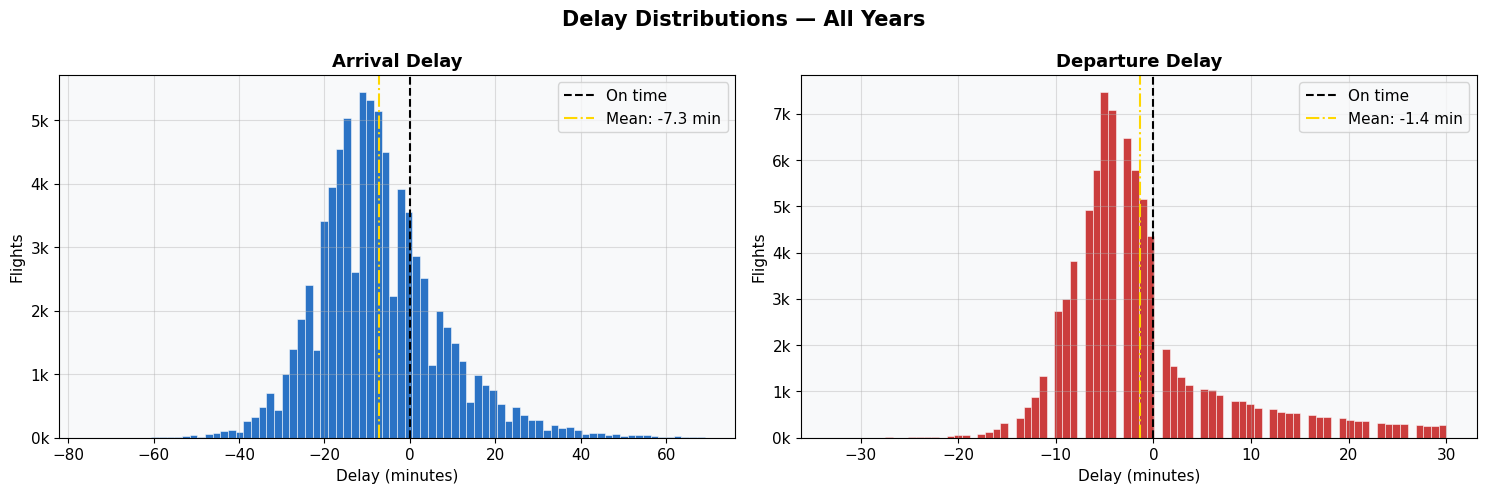

In [20]:
# VIZ 1 — Arrival and departure delay distributions
samp = to_pd(df.select('arr_delay','dep_delay'), n=80000)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Delay Distributions — All Years', fontsize=15, fontweight='bold')

for ax, c, color, title in zip(
    axes,
    ['arr_delay','dep_delay'],
    [PAL[0], PAL[1]],
    ['Arrival Delay','Departure Delay'],
):
    ax.hist(samp[c], bins=80, color=color, edgecolor='white', lw=0.4, alpha=0.9)
    ax.axvline(0, color='black', lw=1.5, ls='--', label='On time')
    ax.axvline(samp[c].mean(), color='gold', lw=1.5, ls='-.',
               label=f'Mean: {samp[c].mean():.1f} min')
    ax.set_xlabel('Delay (minutes)')
    ax.set_ylabel('Flights')
    ax.set_title(title)
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))

plt.tight_layout()
save_fig('viz_01_distributions')
plt.show()

Saved viz_02_status.png


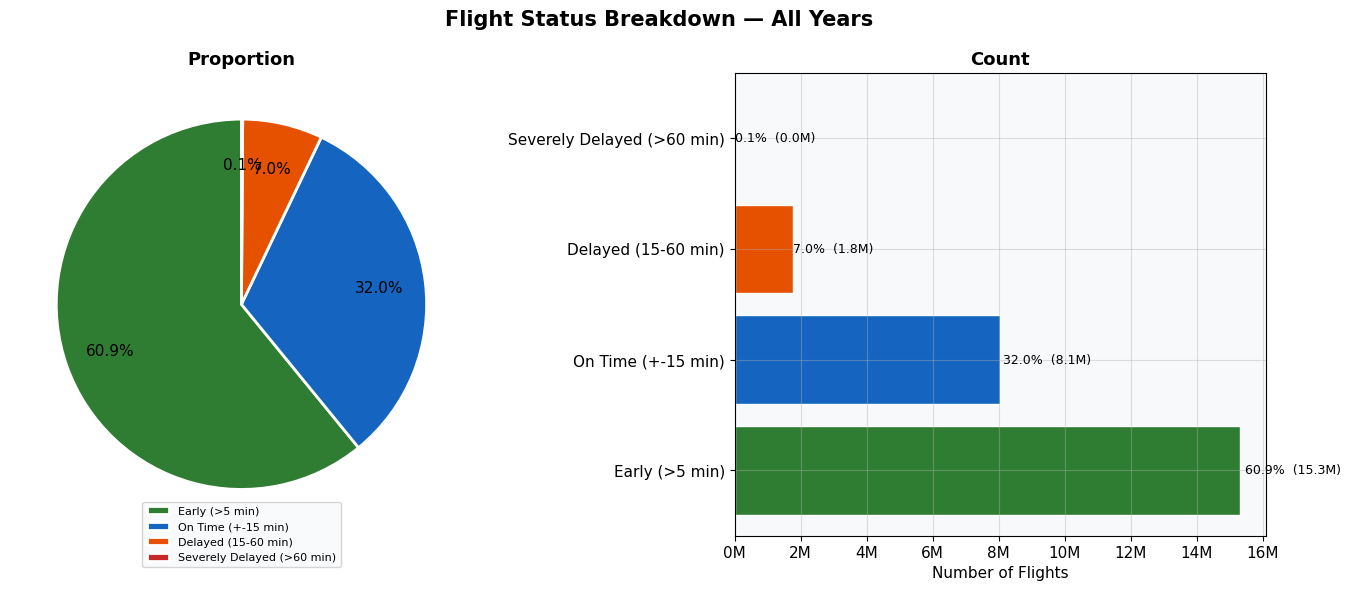

In [21]:
# VIZ 2 — Flight status breakdown (pie + bar)
status_pd = (
    df.withColumn('status',
        when(col('arr_delay') <  -5, 'Early (>5 min)')
        .when(col('arr_delay') <= 15, 'On Time (+-15 min)')
        .when(col('arr_delay') <= 60, 'Delayed (15-60 min)')
        .otherwise('Severely Delayed (>60 min)'))
    .groupBy('status').agg(count('*').alias('flights'))
    .toPandas()
)
order = ['Early (>5 min)','On Time (+-15 min)','Delayed (15-60 min)','Severely Delayed (>60 min)']
status_pd = status_pd.set_index('status').reindex(order).reset_index().dropna()
status_pd['pct'] = (status_pd['flights'] / status_pd['flights'].sum() * 100).round(1)
sc = [PAL[2], PAL[0], PAL[3], PAL[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Flight Status Breakdown — All Years', fontsize=15, fontweight='bold')

wedges,_,_ = axes[0].pie(
    status_pd['flights'], colors=sc, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2},
)
axes[0].legend(wedges, status_pd['status'], loc='lower center',
               bbox_to_anchor=(0.5,-0.08), fontsize=8)
axes[0].set_title('Proportion')

bars = axes[1].barh(status_pd['status'], status_pd['flights'], color=sc, edgecolor='white')
for bar, row in zip(bars, status_pd.itertuples()):
    axes[1].text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                 f'{row.pct}%  ({row.flights/1e6:.1f}M)', va='center', fontsize=9)
axes[1].set_xlabel('Number of Flights')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
axes[1].set_title('Count')

plt.tight_layout()
save_fig('viz_02_status')
plt.show()

Saved viz_03_missing.png


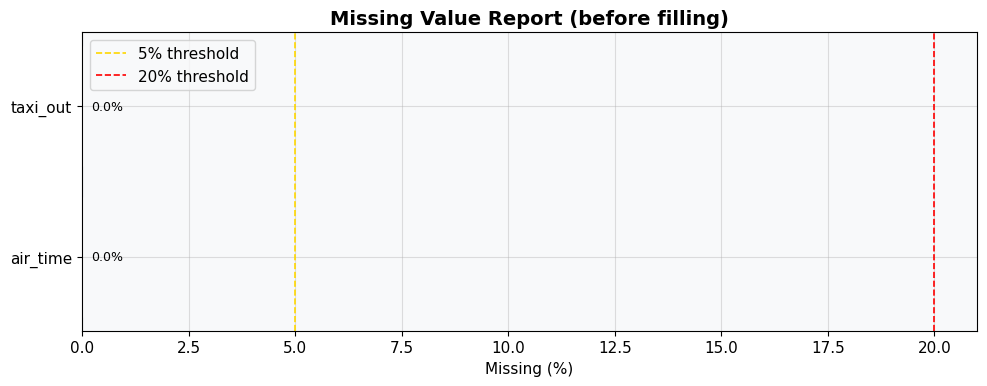

In [22]:
# VIZ 3 — Missing value report bar chart
miss_plot = missing_df[missing_df['pct'] > 0].copy()
if miss_plot.empty:
    print('No missing values remain in the clean DataFrame')
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(miss_plot)*0.45)))
    colors = [PAL[1] if p > 20 else (PAL[3] if p > 5 else PAL[0]) for p in miss_plot['pct']]
    bars = ax.barh(miss_plot['column'], miss_plot['pct'], color=colors, edgecolor='white')
    for bar, (_, row) in zip(bars, miss_plot.iterrows()):
        ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                f'{row["pct"]:.1f}%', va='center', fontsize=9)
    ax.axvline(5,  color='gold', lw=1.2, ls='--', label='5% threshold')
    ax.axvline(20, color='red',  lw=1.2, ls='--', label='20% threshold')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Value Report (before filling)', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    save_fig('viz_03_missing')
    plt.show()

Saved viz_04_yearly.png


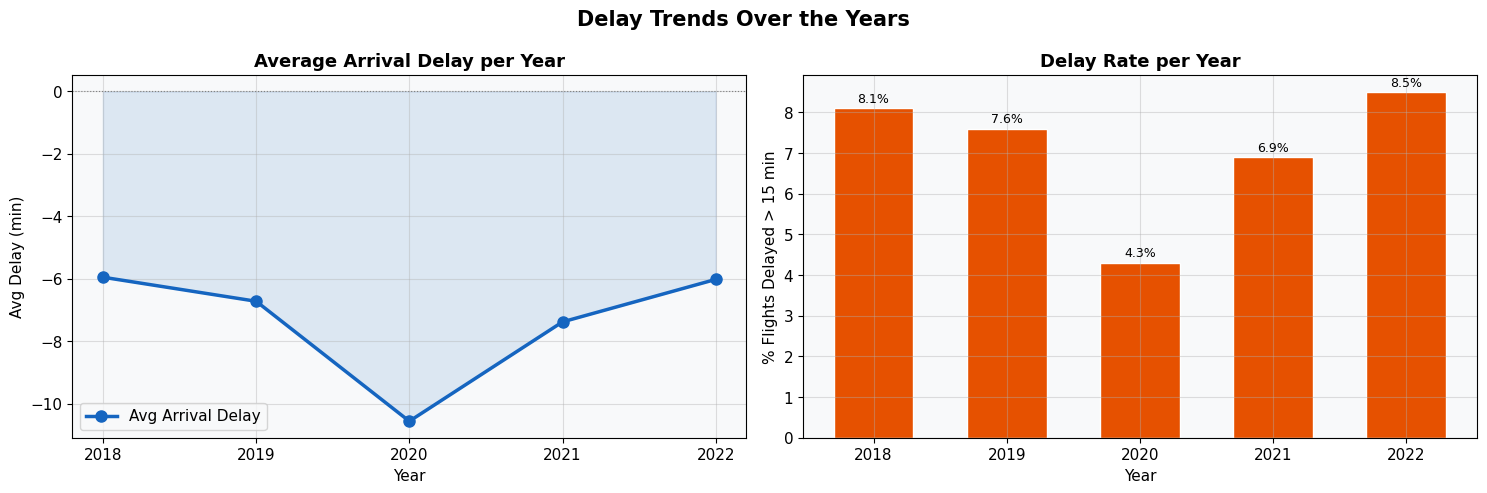

In [23]:
# VIZ 4 — Yearly delay trends
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Delay Trends Over the Years', fontsize=15, fontweight='bold')

axes[0].plot(year_summary['year'], year_summary['avg_arr'],
             'o-', color=PAL[0], lw=2.5, ms=8, label='Avg Arrival Delay')
axes[0].fill_between(year_summary['year'], year_summary['avg_arr'],
                     alpha=0.12, color=PAL[0])
axes[0].axhline(0, color='grey', lw=0.8, ls=':')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Delay (min)')
axes[0].set_title('Average Arrival Delay per Year')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[1].bar(year_summary['year'], year_summary['pct_delayed'],
            color=PAL[3], edgecolor='white', width=0.6)
for x, y in zip(year_summary['year'], year_summary['pct_delayed']):
    axes[1].text(x, y+0.15, f'{y:.1f}%', ha='center', fontsize=9)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Flights Delayed > 15 min')
axes[1].set_title('Delay Rate per Year')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
save_fig('viz_04_yearly')
plt.show()

Saved viz_05_covid.png


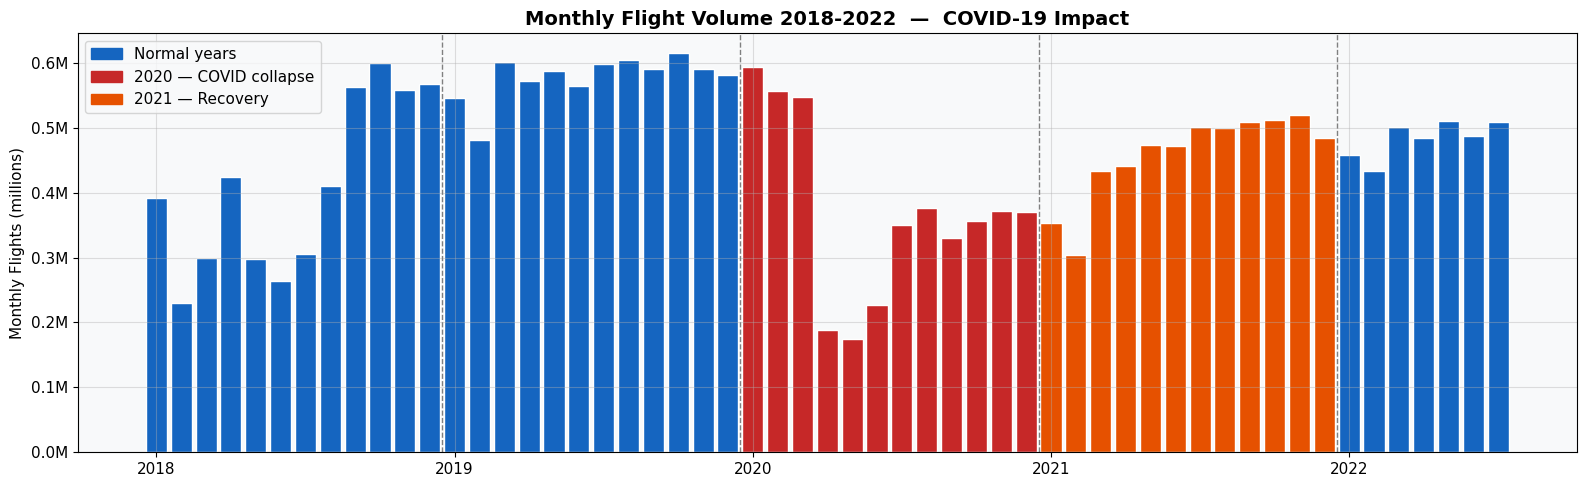

In [24]:
# VIZ 5 — COVID-19 impact: monthly flight volume
covid_pd = (
    df.groupBy('year','month')
    .agg(count('*').alias('flights'))
    .orderBy('year','month')
    .toPandas().dropna()
)
covid_pd['year'] = covid_pd['year'].astype(int)
covid_pd['month'] = covid_pd['month'].astype(int)

fig, ax = plt.subplots(figsize=(16, 5))
color_map = {2018: PAL[0], 2019: PAL[0], 2020: PAL[1], 2021: PAL[3], 2022: PAL[0]}
bar_colors = [color_map.get(int(r.year), PAL[0]) for r in covid_pd.itertuples()]
ax.bar(range(len(covid_pd)), covid_pd['flights']/1e6,
       color=bar_colors, edgecolor='white', width=0.85)

# Year boundary lines
for yr in [2019, 2020, 2021, 2022]:
    idx = covid_pd[covid_pd['year']==yr].index
    if len(idx): ax.axvline(idx[0]-0.5, color='grey', lw=1, ls='--')

year_starts = [covid_pd[covid_pd['year']==yr].index[0]
               for yr in [2018,2019,2020,2021,2022]
               if len(covid_pd[covid_pd['year']==yr]) > 0]
ax.set_xticks(year_starts)
ax.set_xticklabels(['2018','2019','2020','2021','2022'])
ax.set_ylabel('Monthly Flights (millions)')
ax.set_title('Monthly Flight Volume 2018-2022  —  COVID-19 Impact',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PAL[0], label='Normal years'),
    Patch(color=PAL[1], label='2020 — COVID collapse'),
    Patch(color=PAL[3], label='2021 — Recovery'),
])
plt.tight_layout()
save_fig('viz_05_covid')
plt.show()

Saved viz_06_monthly.png


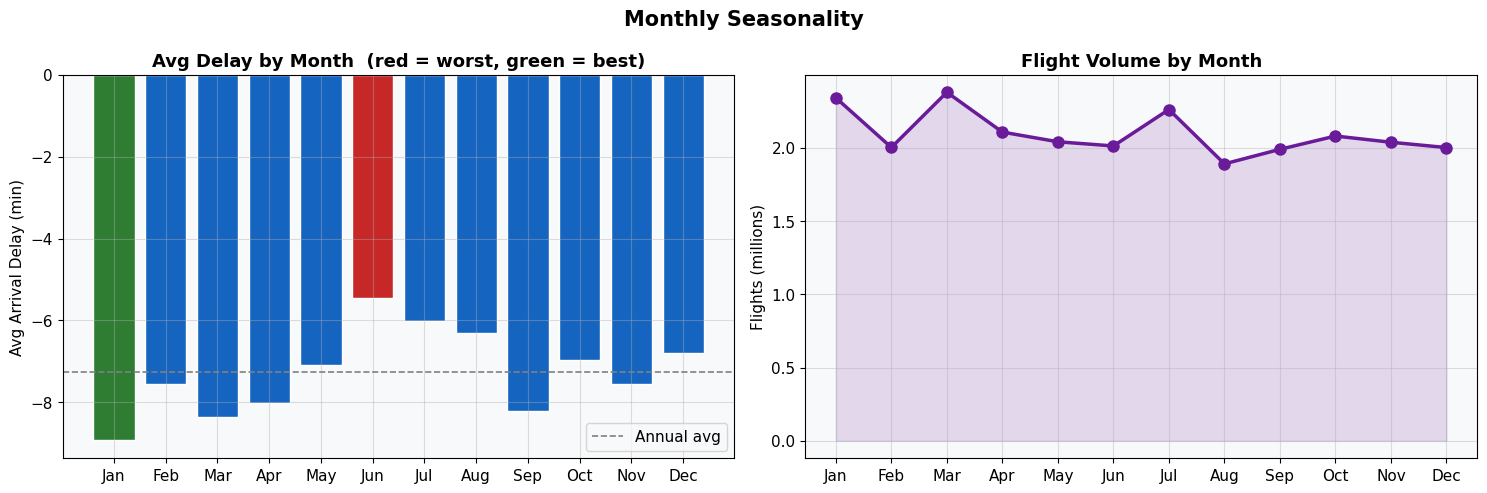

In [25]:
# VIZ 6 — Monthly seasonality
month_pd = (
    df.groupBy('month')
    .agg(
        spark_round(avg('arr_delay'), 2).alias('avg_arr'),
        count('*').alias('flights'),
    )
    .orderBy('month').toPandas().dropna()
)
MN = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_pd['name'] = month_pd['month'].apply(lambda m: MN[int(m)-1])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Monthly Seasonality', fontsize=15, fontweight='bold')

worst_m = month_pd['avg_arr'].idxmax()
best_m  = month_pd['avg_arr'].idxmin()
c_m = [PAL[1] if i==worst_m else (PAL[2] if i==best_m else PAL[0]) for i in month_pd.index]
axes[0].bar(month_pd['name'], month_pd['avg_arr'], color=c_m, edgecolor='white')
axes[0].axhline(month_pd['avg_arr'].mean(), color='grey', lw=1.2, ls='--', label='Annual avg')
axes[0].set_ylabel('Avg Arrival Delay (min)')
axes[0].set_title('Avg Delay by Month  (red = worst, green = best)')
axes[0].legend()

axes[1].plot(month_pd['name'], month_pd['flights']/1e6, 'o-', color=PAL[4], lw=2.5, ms=8)
axes[1].fill_between(range(len(month_pd)), month_pd['flights']/1e6, alpha=0.15, color=PAL[4])
axes[1].set_ylabel('Flights (millions)')
axes[1].set_title('Flight Volume by Month')

plt.tight_layout()
save_fig('viz_06_monthly')
plt.show()

Saved viz_07_airlines.png


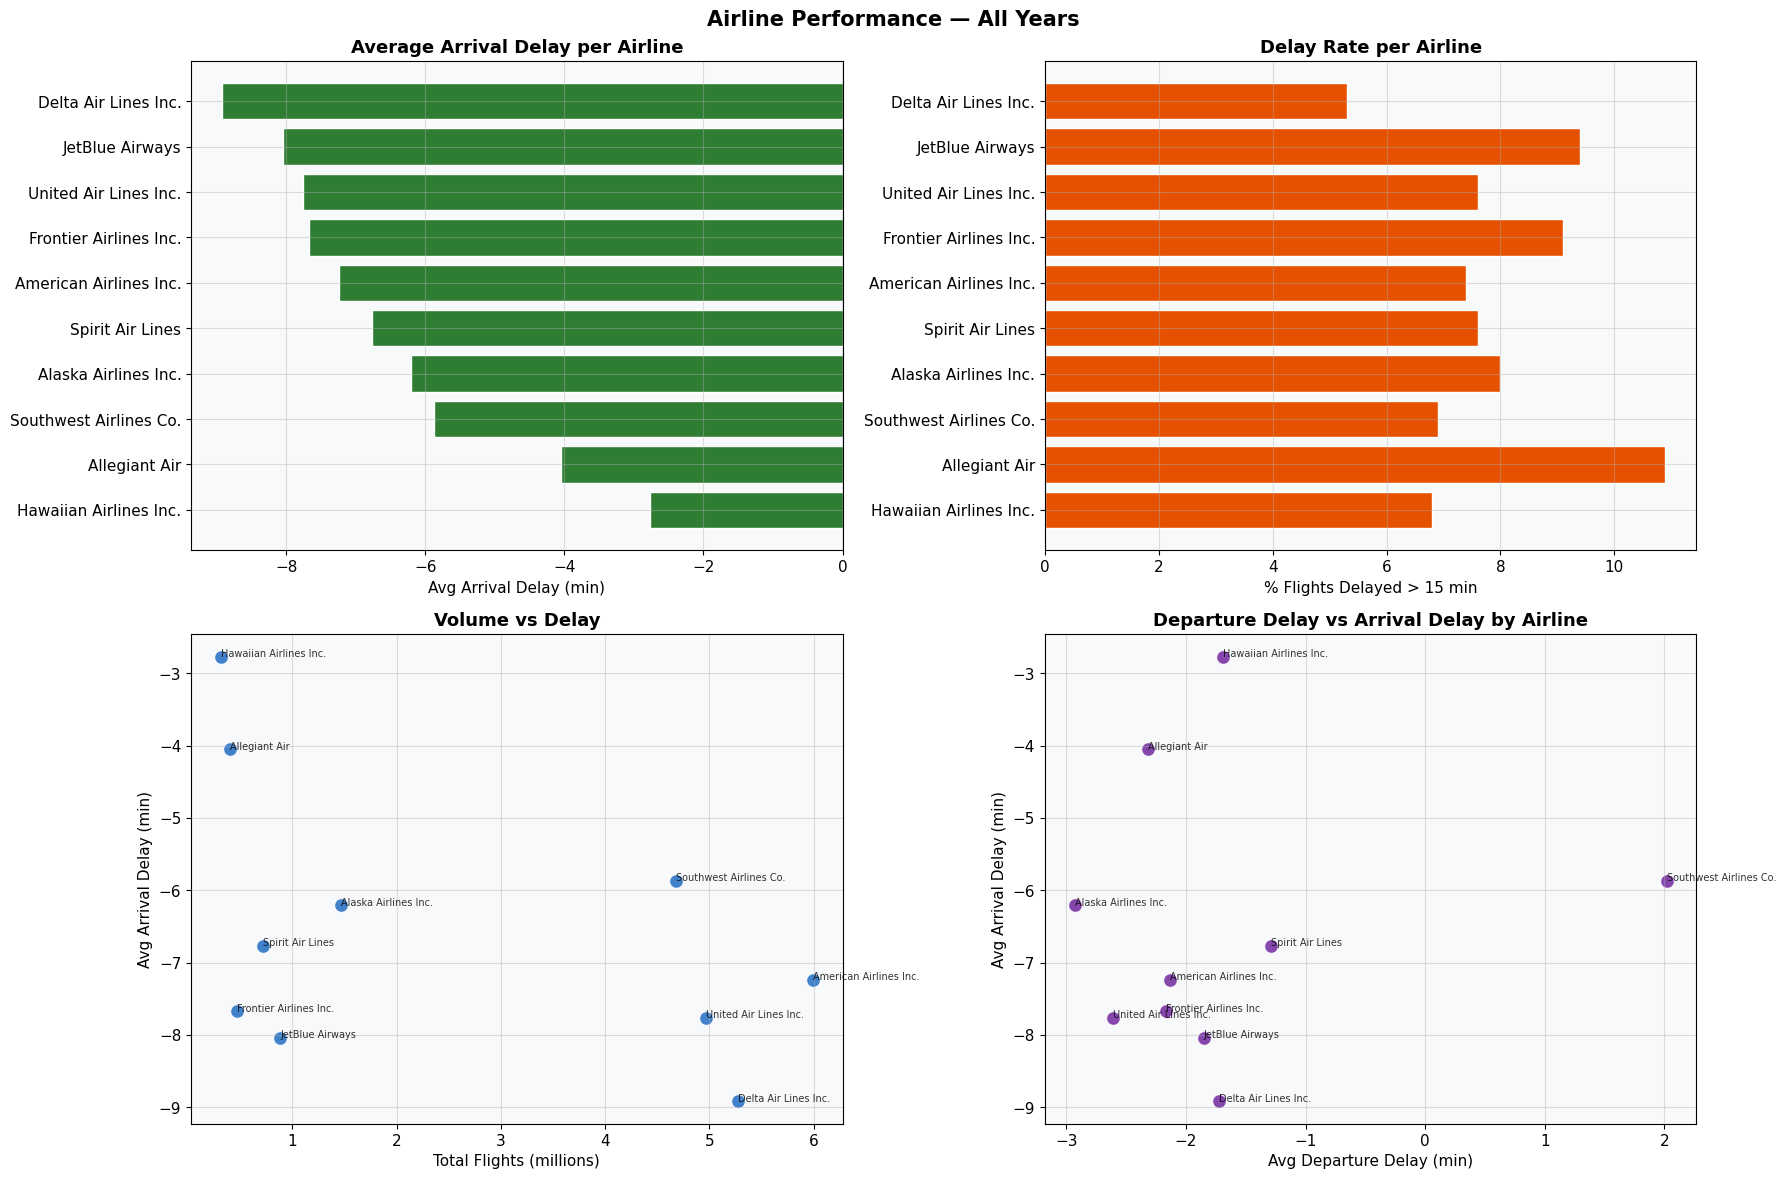

In [26]:
# VIZ 7 — Airline performance (4-panel)
airline_pd = (
    df.groupBy('airline_name')
    .agg(
        spark_round(avg('arr_delay'), 2).alias('avg_arr'),
        spark_round(avg('dep_delay'), 2).alias('avg_dep'),
        count('*').alias('flights'),
        spark_round(
            count(when(col('arr_delay') > 15, 1)) * 100.0 / count('*'), 1
        ).alias('pct_delayed'),
    )
    .filter(col('flights') >= 50000)
    .orderBy('avg_arr', ascending=False)
    .toPandas()
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Airline Performance — All Years', fontsize=15, fontweight='bold')

c_a = [PAL[1] if v >= 0 else PAL[2] for v in airline_pd['avg_arr']]
axes[0,0].barh(airline_pd['airline_name'], airline_pd['avg_arr'], color=c_a, edgecolor='white')
axes[0,0].axvline(0, color='black', lw=0.8)
axes[0,0].set_xlabel('Avg Arrival Delay (min)')
axes[0,0].set_title('Average Arrival Delay per Airline')

axes[0,1].barh(airline_pd['airline_name'], airline_pd['pct_delayed'],
               color=PAL[3], edgecolor='white')
axes[0,1].set_xlabel('% Flights Delayed > 15 min')
axes[0,1].set_title('Delay Rate per Airline')

axes[1,0].scatter(airline_pd['flights']/1e6, airline_pd['avg_arr'],
                  s=100, color=PAL[0], alpha=0.8, edgecolors='white')
for _, row in airline_pd.iterrows():
    short = str(row['airline_name']).split(' d/b/a')[0].split(',')[0][:22]
    axes[1,0].annotate(short, (row['flights']/1e6, row['avg_arr']), fontsize=7, alpha=0.8)
axes[1,0].set_xlabel('Total Flights (millions)')
axes[1,0].set_ylabel('Avg Arrival Delay (min)')
axes[1,0].set_title('Volume vs Delay')

axes[1,1].scatter(airline_pd['avg_dep'], airline_pd['avg_arr'],
                  s=100, color=PAL[4], alpha=0.8, edgecolors='white')
for _, row in airline_pd.iterrows():
    short = str(row['airline_name']).split(' d/b/a')[0].split(',')[0][:22]
    axes[1,1].annotate(short, (row['avg_dep'], row['avg_arr']), fontsize=7, alpha=0.8)
axes[1,1].set_xlabel('Avg Departure Delay (min)')
axes[1,1].set_ylabel('Avg Arrival Delay (min)')
axes[1,1].set_title('Departure Delay vs Arrival Delay by Airline')

plt.tight_layout()
save_fig('viz_07_airlines')
plt.show()

Saved viz_08_day_of_week.png


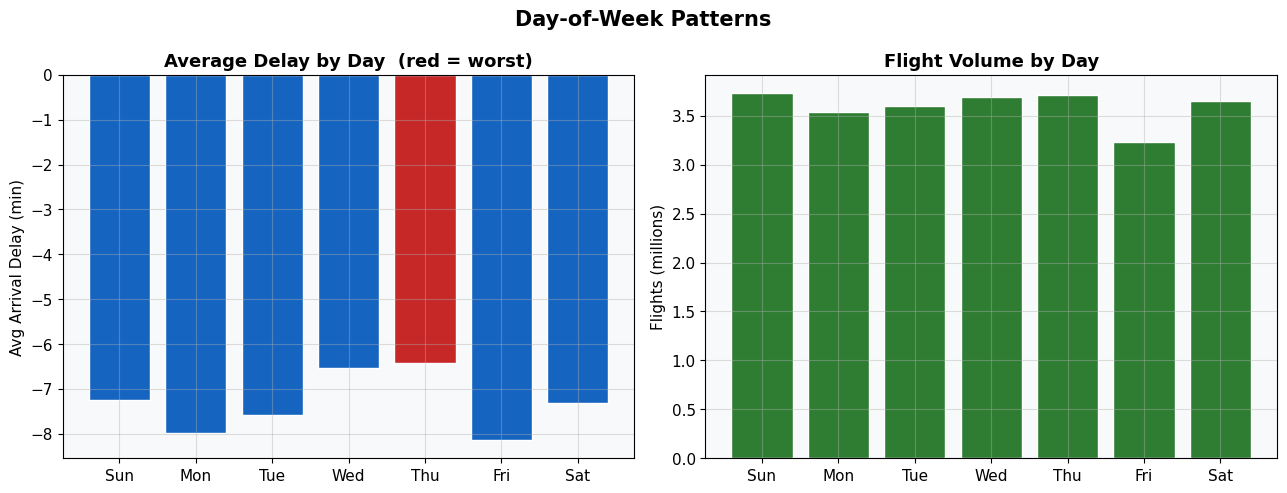

In [27]:
# VIZ 8 — Day-of-week analysis
dow_pd = (
    df.groupBy('day_of_week')
    .agg(
        spark_round(avg('arr_delay'), 2).alias('avg_arr'),
        count('*').alias('flights'),
    )
    .orderBy('day_of_week').toPandas().dropna()
)
day_names = {1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'}
dow_pd['day'] = dow_pd['day_of_week'].map(day_names)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Day-of-Week Patterns', fontsize=15, fontweight='bold')

worst_d = dow_pd['avg_arr'].idxmax()
c_d = [PAL[1] if i == worst_d else PAL[0] for i in dow_pd.index]
axes[0].bar(dow_pd['day'], dow_pd['avg_arr'], color=c_d, edgecolor='white')
axes[0].set_ylabel('Avg Arrival Delay (min)')
axes[0].set_title('Average Delay by Day  (red = worst)')

axes[1].bar(dow_pd['day'], dow_pd['flights']/1e6, color=PAL[2], edgecolor='white')
axes[1].set_ylabel('Flights (millions)')
axes[1].set_title('Flight Volume by Day')

plt.tight_layout()
save_fig('viz_08_day_of_week')
plt.show()

Saved viz_09_heatmap.png


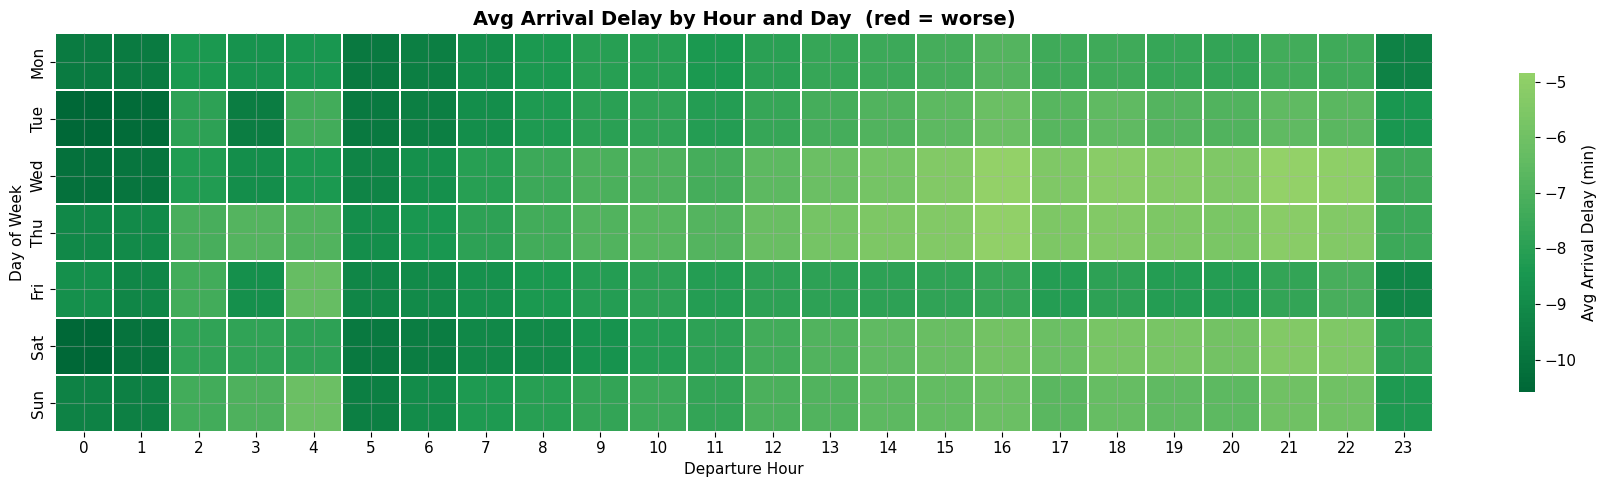

In [ ]:
# VIZ 9 — Departure hour x day-of-week heatmap
heat_pd = (
    df.groupBy('dep_hour','day_of_week')
    .agg(spark_round(avg('arr_delay'), 2).alias('avg_delay'))
    .toPandas().dropna()
)
heat_pd = heat_pd[heat_pd['dep_hour'].between(0, 23)]
day_names_h = {1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'}
heat_pd['day_name'] = heat_pd['day_of_week'].map(day_names_h)
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

pivot = heat_pd.pivot_table(index='day_name', columns='dep_hour', values='avg_delay')
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot, cmap='RdYlGn_r', center=0, ax=ax,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label':'Avg Arrival Delay (min)', 'shrink':0.8})
ax.set_xlabel('Departure Hour')
ax.set_ylabel('Day of Week')
ax.set_title('Avg Arrival Delay by Hour and Day',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('viz_09_heatmap')
plt.show()

In [29]:
# VIZ 10 — Delay cause breakdown
cause_cols_present = [c for c in
    ['carrier_delay','weather_delay','nas_delay','late_aircraft_delay']
    if c in df.columns]

if cause_cols_present:
    cause_pd = df.filter(col('arr_delay') > 15).agg(
        *[spark_round(avg(c), 2).alias(c) for c in cause_cols_present]
    ).toPandas().T.reset_index()
    cause_pd.columns = ['cause','avg_minutes']
    cause_pd['cause'] = cause_pd['cause'].str.replace('_', ' ').str.title()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Delay Cause Breakdown  (delayed flights only)',
                 fontsize=15, fontweight='bold')
    axes[0].barh(cause_pd['cause'], cause_pd['avg_minutes'],
                 color=PAL[:len(cause_pd)], edgecolor='white')
    axes[0].set_xlabel('Avg Minutes of Delay')
    axes[0].set_title('Average Contribution per Cause')
    axes[1].pie(cause_pd['avg_minutes'], labels=cause_pd['cause'],
                colors=PAL[:len(cause_pd)], autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor':'white','linewidth':1.5})
    axes[1].set_title('Proportional Share')
    plt.tight_layout()
    save_fig('viz_10_causes')
    plt.show()
else:
    print('No delay cause columns found — skipping')

No delay cause columns found — skipping


Saved viz_11_routes.png


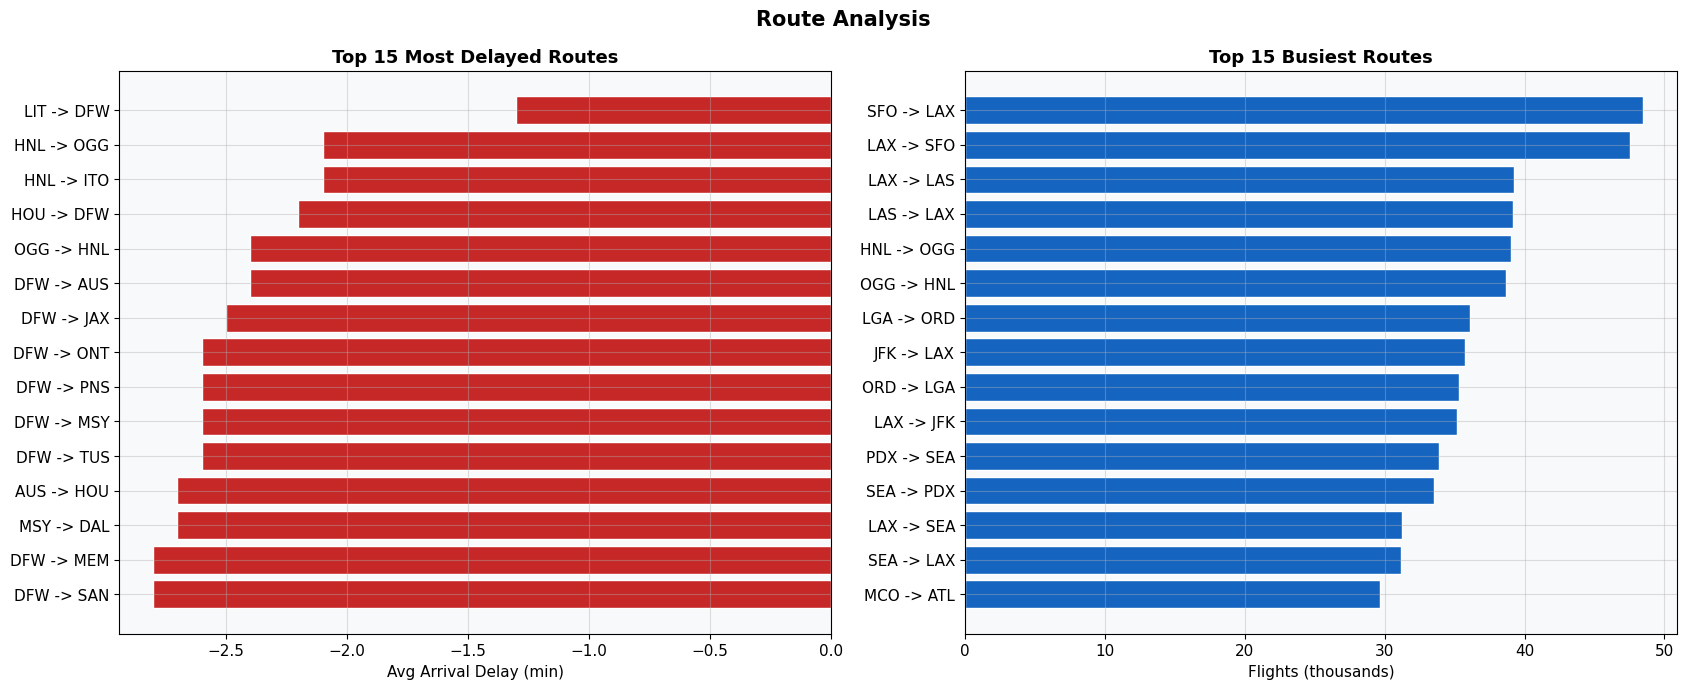

In [30]:
# VIZ 11 — Top routes
routes_pd = (
    df.withColumn('route', concat_ws(' -> ', col('origin'), col('dest')))
    .groupBy('route')
    .agg(
        spark_round(avg('arr_delay'), 1).alias('avg_delay'),
        count('*').alias('flights'),
    )
    .filter(col('flights') >= 5000)
)
top_delayed  = routes_pd.orderBy('avg_delay',  ascending=False).limit(15).toPandas()
most_flights = routes_pd.orderBy('flights',     ascending=False).limit(15).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Route Analysis', fontsize=15, fontweight='bold')
axes[0].barh(top_delayed['route'][::-1],   top_delayed['avg_delay'][::-1],
             color=PAL[1], edgecolor='white')
axes[0].set_xlabel('Avg Arrival Delay (min)')
axes[0].set_title('Top 15 Most Delayed Routes')
axes[1].barh(most_flights['route'][::-1],  most_flights['flights'][::-1]/1e3,
             color=PAL[0], edgecolor='white')
axes[1].set_xlabel('Flights (thousands)')
axes[1].set_title('Top 15 Busiest Routes')
plt.tight_layout()
save_fig('viz_11_routes')
plt.show()

Saved viz_12_airports.png


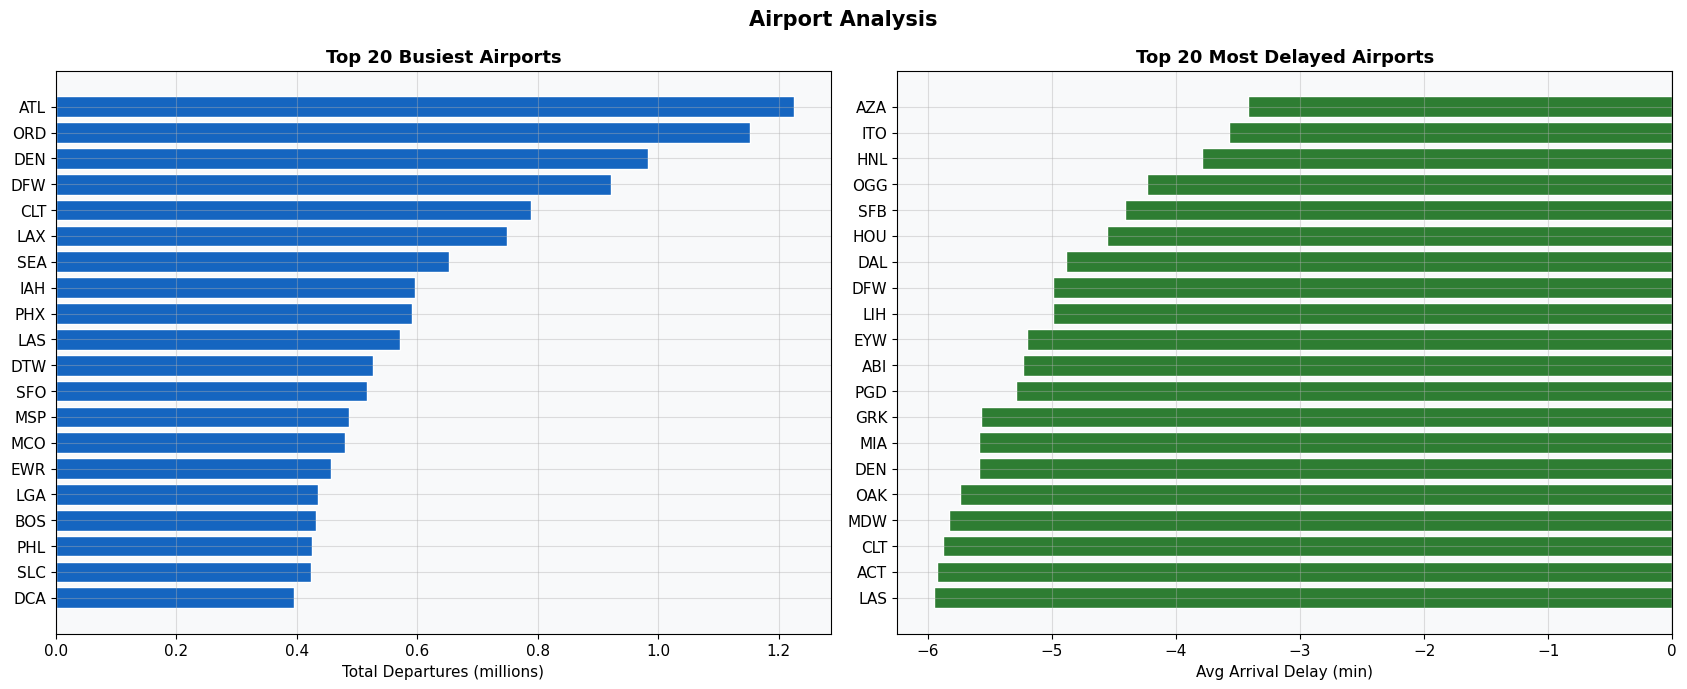

In [31]:
# VIZ 12 — Airport analysis
airport_pd = (
    df.groupBy('origin')
    .agg(
        spark_round(avg('arr_delay'), 2).alias('avg_delay'),
        count('*').alias('flights'),
    )
    .filter(col('flights') >= 5000)
    .toPandas()
)
top_busy    = airport_pd.nlargest(20, 'flights')
top_delayed = airport_pd.nlargest(20, 'avg_delay')

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Airport Analysis', fontsize=15, fontweight='bold')
axes[0].barh(top_busy['origin'][::-1],    top_busy['flights'][::-1]/1e6,
             color=PAL[0], edgecolor='white')
axes[0].set_xlabel('Total Departures (millions)')
axes[0].set_title('Top 20 Busiest Airports')
c_ap = [PAL[1] if v > 0 else PAL[2] for v in top_delayed['avg_delay'][::-1]]
axes[1].barh(top_delayed['origin'][::-1], top_delayed['avg_delay'][::-1],
             color=c_ap, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Avg Arrival Delay (min)')
axes[1].set_title('Top 20 Most Delayed Airports')
plt.tight_layout()
save_fig('viz_12_airports')
plt.show()

Saved viz_13_correlation.png


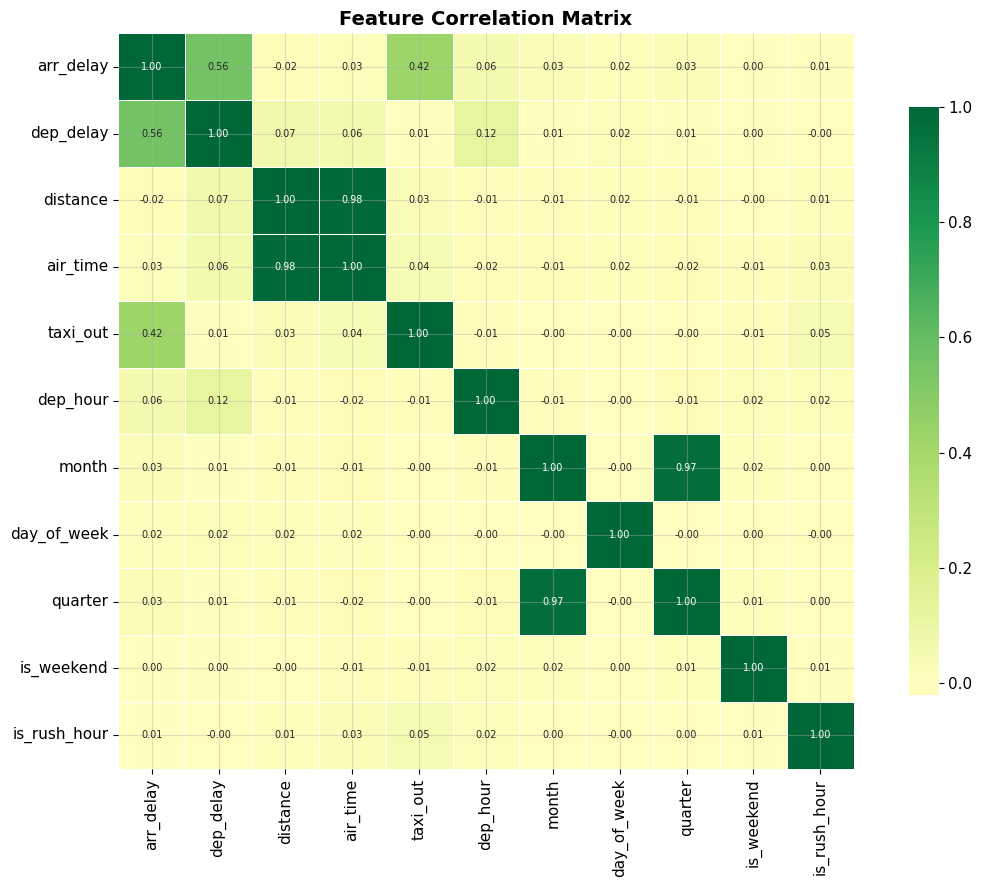


Correlation with arr_delay:
  dep_delay                 +0.558
  distance                  -0.021
  air_time                  +0.025
  taxi_out                  +0.425
  dep_hour                  +0.062
  month                     +0.032
  day_of_week               +0.017
  quarter                   +0.032
  is_weekend                +0.005
  is_rush_hour              +0.011


In [32]:
# VIZ 13 — Correlation heatmap
num_cols = [c for c in ['arr_delay','dep_delay','distance','air_time','taxi_out',
                         'dep_hour','month','day_of_week','quarter',
                         'is_weekend','is_rush_hour','carrier_delay',
                         'weather_delay','nas_delay','late_aircraft_delay']
            if c in df.columns]

corr_samp   = to_pd(df.select(num_cols), n=30000)
corr_matrix = corr_samp.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'shrink':0.8}, annot_kws={'size':7})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('viz_13_correlation')
plt.show()

print('\nCorrelation with arr_delay:')
for c in [x for x in num_cols if x != 'arr_delay']:
    print(f'  {c:<25} {corr_matrix.loc["arr_delay",c]:+.3f}')

Saved viz_14_scatter.png


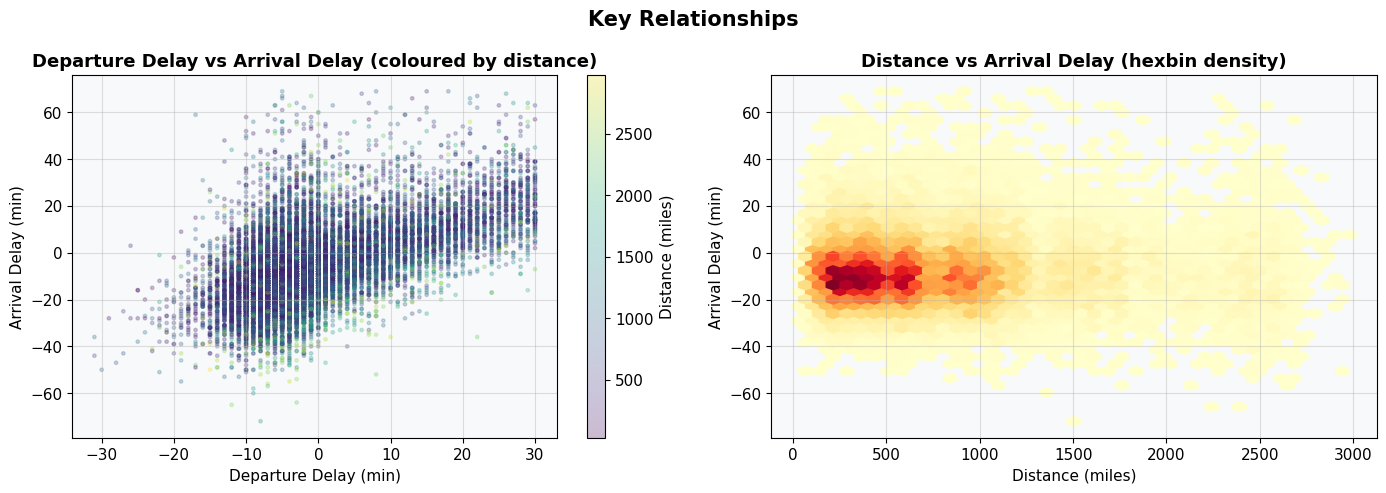

In [33]:
# VIZ 14 — Scatter: dep_delay vs arr_delay + distance vs arr_delay
scat = to_pd(df.select('dep_delay','arr_delay','distance'), n=25000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Key Relationships', fontsize=15, fontweight='bold')

sc = axes[0].scatter(scat['dep_delay'], scat['arr_delay'],
                     c=scat['distance'], cmap='viridis', alpha=0.25, s=6)
plt.colorbar(sc, ax=axes[0], label='Distance (miles)')
axes[0].set_xlabel('Departure Delay (min)')
axes[0].set_ylabel('Arrival Delay (min)')
axes[0].set_title('Departure Delay vs Arrival Delay (coloured by distance)')

axes[1].hexbin(scat['distance'], scat['arr_delay'], gridsize=40, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('Arrival Delay (min)')
axes[1].set_title('Distance vs Arrival Delay (hexbin density)')

plt.tight_layout()
save_fig('viz_14_scatter')
plt.show()

Saved viz_15_yearly_boxplot.png


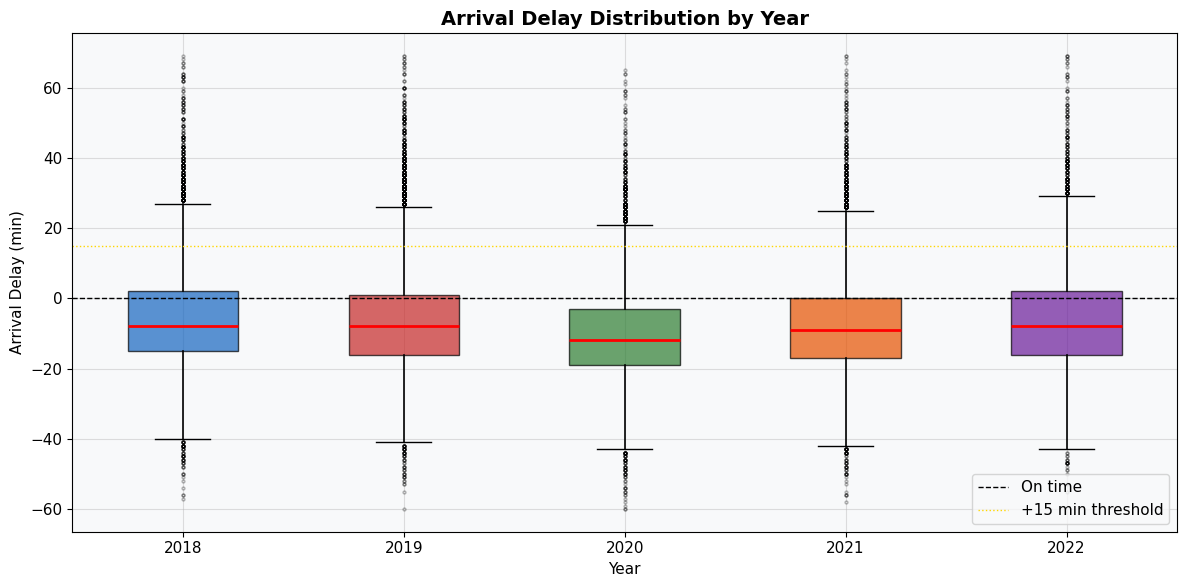

In [34]:
# VIZ 15 — Yearly delay distribution boxplot
box_pd = to_pd(df.select('year','arr_delay'), n=60000)
box_pd = box_pd[box_pd['arr_delay'].between(-60, 180)]
years_sorted = sorted(box_pd['year'].unique().astype(int))
grouped = [box_pd[box_pd['year']==yr]['arr_delay'].values for yr in years_sorted]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(grouped, labels=years_sorted, patch_artist=True,
                medianprops={'color':'red','lw':2},
                whiskerprops={'lw':1.2},
                flierprops={'markersize':2,'alpha':0.3})
for patch, color in zip(bp['boxes'], PAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0,  color='black', lw=1,   ls='--', label='On time')
ax.axhline(15, color='gold',  lw=1,   ls=':',  label='+15 min threshold')
ax.set_xlabel('Year')
ax.set_ylabel('Arrival Delay (min)')
ax.set_title('Arrival Delay Distribution by Year', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('viz_15_yearly_boxplot')
plt.show()

---
## Section 6 — ML Feature Preparation

The pipeline indexes categorical columns with StringIndexer,
then assembles all features into a single vector column.
The same feature set is used for both regression and classification.

In [ ]:
stages = []
cat_output_cols = []

#StringIndex each categorical column
for cat in ['airline', 'origin', 'dest']:
    if cat in df.columns:
        idx = StringIndexer(
            inputCol=cat, outputCol=f'{cat}_idx', handleInvalid='keep'
        )
        stages.append(idx)
        cat_output_cols.append(f'{cat}_idx')

#Numeric features
num_features = ['dep_delay','distance']
num_features += [c for c in [
    'air_time','taxi_out','dep_hour','month','day_of_week',
    'quarter','is_weekend','is_rush_hour','dep_period',
    'carrier_delay','weather_delay','nas_delay','late_aircraft_delay',
] if c in df.columns]

FEATURE_COLS = num_features + cat_output_cols
LABEL        = 'arr_delay'

assembler = VectorAssembler(
    inputCols=FEATURE_COLS, outputCol='features', handleInvalid='skip'
)
stages.append(assembler)

print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Label column   : {LABEL}')

Feature columns (14): ['dep_delay', 'distance', 'air_time', 'taxi_out', 'dep_hour', 'month', 'day_of_week', 'quarter', 'is_weekend', 'is_rush_hour', 'dep_period', 'airline_idx', 'origin_idx', 'dest_idx']
Label column   : arr_delay


In [ ]:
#Fit prep pipeline and transform
prep_model = Pipeline(stages=stages).fit(df)
df_ml = prep_model.transform(df).select('features', LABEL)

# 80/20 train/test split
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()

print(f'Train rows : {train_df.count():,}')
print(f'Test rows  : {test_df.count():,}')

Train rows : 20,127,857
Test rows  : 5,033,063


---
## Section 7 — Regression Models

Task: predict the exact arrival delay in minutes.

| Model | Key property |
|-------|-------------|
| Linear Regression | Fast interpretable baseline |
| Decision Tree | Rule-based splits, easy to explain |
| Random Forest | Ensemble of 50 trees, robust to noise |
| GBT | Sequential boosting, typically the strongest |

Metrics: RMSE (lower is better), MAE (lower is better), R-squared (higher is better).

In [37]:
def eval_reg(preds):
    ev = RegressionEvaluator(labelCol=LABEL, predictionCol='prediction')
    return {
        'rmse': ev.setMetricName('rmse').evaluate(preds),
        'mae':  ev.setMetricName('mae').evaluate(preds),
        'r2':   ev.setMetricName('r2').evaluate(preds),
    }

results_reg = {}
print('Regression evaluator ready')

Regression evaluator ready


In [ ]:
#Model 1 — Linear Regression
print('Training Linear Regression...')
t0 = time.time()
lr = LinearRegression(
    featuresCol='features', labelCol=LABEL,
    maxIter=100, regParam=0.1,
).fit(train_df)
lr_preds = lr.transform(test_df)
results_reg['Linear Regression'] = {**eval_reg(lr_preds), 'time': round(time.time()-t0,1)}
r = results_reg['Linear Regression']
print(f'  RMSE={r["rmse"]:.3f}  MAE={r["mae"]:.3f}  R2={r["r2"]:.4f}  ({r["time"]}s)')

Training Linear Regression...
  RMSE=9.779  MAE=7.249  R2=0.5596  (7.2s)


In [ ]:
#Model 2 — Decision Tree
print('Training Decision Tree...')
t0 = time.time()
dt = DecisionTreeRegressor(
    featuresCol='features', labelCol=LABEL,
    maxDepth=10, minInstancesPerNode=20,
    maxBins=512,
).fit(train_df)
dt_preds = dt.transform(test_df)
results_reg['Decision Tree'] = {
    **eval_reg(dt_preds), 'time': round(time.time()-t0,1),
    'importances': dt.featureImportances,
}
r = results_reg['Decision Tree']
print(f'  RMSE={r["rmse"]:.3f}  MAE={r["mae"]:.3f}  R2={r["r2"]:.4f}  ({r["time"]}s)')

Training Decision Tree...
  RMSE=10.043  MAE=7.369  R2=0.5355  (20.6s)


In [ ]:
#Model 3 — Random Forest
print('Training Random Forest (may take 2-4 min)...')
t0 = time.time()
rf = RandomForestRegressor(
    featuresCol='features', labelCol=LABEL,
    numTrees=100, maxDepth=10, minInstancesPerNode=20,
    maxBins=512,   # <-- same fix
    seed=42,
).fit(train_df)
rf_preds = rf.transform(test_df)
results_reg['Random Forest'] = {
    **eval_reg(rf_preds), 'time': round(time.time()-t0,1),
    'importances': rf.featureImportances,
}
r = results_reg['Random Forest']
print(f'  RMSE={r["rmse"]:.3f}  MAE={r["mae"]:.3f}  R2={r["r2"]:.4f}  ({r["time"]}s)')

Training Random Forest (may take 2-4 min)...
  RMSE=9.965  MAE=7.315  R2=0.5426  (1614.7s)


In [ ]:
#Model 4 — Gradient Boosted Trees
print('Training GBT (may take 3-6 min)...')
t0 = time.time()
gbt = GBTRegressor(
    featuresCol='features', labelCol=LABEL,
    maxDepth=8, maxIter=50, minInstancesPerNode=20,
    maxBins=512,   # <-- same fix
    seed=42,
).fit(train_df)
gbt_preds = gbt.transform(test_df)
results_reg['GBT'] = {
    **eval_reg(gbt_preds), 'time': round(time.time()-t0,1),
    'importances': gbt.featureImportances,
}
r = results_reg['GBT']
print(f'  RMSE={r["rmse"]:.3f}  MAE={r["mae"]:.3f}  R2={r["r2"]:.4f}  ({r["time"]}s)')

Training GBT (may take 3-6 min)...
  RMSE=7.346  MAE=5.339  R2=0.7515  (683.3s)


---
## Section 7b — Cross-Validation on the Best Regression Model

3-fold cross-validation tunes maxDepth and stepSize on the GBT model.
This prevents overfitting and finds the optimal hyperparameter combination.

In [44]:
print('Running 3-fold cross-validation on GBT (may take 8-12 min)...')
t0 = time.time()

cv_gbt = GBTRegressor(
    featuresCol='features', labelCol=LABEL,
    maxIter=30, subsamplingRate=0.8, seed=42,
    maxBins=512,   # <-- add this
)
param_grid = (
    ParamGridBuilder()
    .addGrid(cv_gbt.maxDepth, [5, 8])
    .addGrid(cv_gbt.stepSize, [0.05, 0.1])
    .build()
)
cv_evaluator = RegressionEvaluator(
    labelCol=LABEL, predictionCol='prediction', metricName='rmse'
)
cv = CrossValidator(
    estimator=cv_gbt,
    estimatorParamMaps=param_grid,
    evaluator=cv_evaluator,
    numFolds=3,
    seed=42,
)
cv_model  = cv.fit(train_df)
cv_preds  = cv_model.transform(test_df)

best_depth = cv_model.bestModel.getMaxDepth()
best_step  = cv_model.bestModel.getStepSize()
results_reg['GBT (CV-tuned)'] = {
    **eval_reg(cv_preds),
    'time': round(time.time()-t0, 1),
    'importances': cv_model.bestModel.featureImportances,
}
r = results_reg['GBT (CV-tuned)']
print(f'  Best maxDepth : {best_depth}')
print(f'  Best stepSize : {best_step}')
print(f'  RMSE={r["rmse"]:.3f}  MAE={r["mae"]:.3f}  R2={r["r2"]:.4f}  ({r["time"]}s)')

Running 3-fold cross-validation on GBT (may take 8-12 min)...
  Best maxDepth : 8
  Best stepSize : 0.1
  RMSE=7.895  MAE=5.797  R2=0.7129  (3768.2s)


---
## Section 8 — Classification Models

Task: predict whether a flight will be delayed by more than 15 minutes.
Label: is_delayed = 1 if arr_delay > 15, else 0.

| Model | Key property |
|-------|-------------|
| Logistic Regression | Fast probabilistic baseline |
| Random Forest Classifier | Robust ensemble, handles non-linearity |
| GBT Classifier | Sequential boosting, typically strongest |

Metrics: Accuracy, Precision, Recall, F1, AUC-ROC.

In [46]:
df_cls.printSchema()

root
 |-- features: vector (nullable = true)
 |-- arr_delay: double (nullable = true)
 |-- is_delayed: double (nullable = false)



In [ ]:
# Create binary label
CLS_LABEL = 'is_delayed'
df_cls = prep_model.transform(df).select('features', LABEL)
df_cls = df_cls.withColumn('is_delayed',
    when(col(LABEL) > 15, 1.0).otherwise(0.0))

# Cache first, then get both counts in ONE aggregation pass
df_cls.cache()
stats = df_cls.agg(
    count('*').alias('total'),
    count(when(col(CLS_LABEL) == 1.0, 1)).alias('delayed')
).collect()[0]

total_cls   = stats['total']
delayed_n   = stats['delayed']
not_delayed = total_cls - delayed_n

print(f'Not delayed : {not_delayed:,}  ({not_delayed/total_cls*100:.1f}%)')
print(f'Delayed     : {delayed_n:,}  ({delayed_n/total_cls*100:.1f}%)')

train_cls, test_cls = (
    df_cls.select('features', CLS_LABEL)
    .randomSplit([0.8, 0.2], seed=42)
)
train_cls.cache()
test_cls.cache()
print(f'Train : {train_cls.count():,}  |  Test : {test_cls.count():,}')

Not delayed : 23,375,191  (92.9%)
Delayed     : 1,785,729  (7.1%)
Train : 20,127,857  |  Test : 5,033,063


In [ ]:
def eval_cls(preds):
    bc = BinaryClassificationEvaluator(
        labelCol=CLS_LABEL, rawPredictionCol='rawPrediction')
    mc = MulticlassClassificationEvaluator(
        labelCol=CLS_LABEL, predictionCol='prediction')
    return {
        'auc':       bc.setMetricName('areaUnderROC').evaluate(preds),
        'accuracy':  mc.setMetricName('accuracy').evaluate(preds),
        'f1':        mc.setMetricName('f1').evaluate(preds),
        'precision': mc.setMetricName('weightedPrecision').evaluate(preds),
        'recall':    mc.setMetricName('weightedRecall').evaluate(preds),
    }

results_cls = {}

Classification evaluator ready


In [ ]:
#Cls Model 1 — Logistic Regression
print('Training Logistic Regression...')
t0 = time.time()
log_reg = LogisticRegression(
    featuresCol='features', labelCol=CLS_LABEL,
    maxIter=100, regParam=0.1,
).fit(train_cls)
lr_cls_preds = log_reg.transform(test_cls)
results_cls['Logistic Regression'] = {
    **eval_cls(lr_cls_preds), 'time': round(time.time()-t0,1)
}
r = results_cls['Logistic Regression']
print(f'  Acc={r["accuracy"]:.4f}  F1={r["f1"]:.4f}  AUC={r["auc"]:.4f}  ({r["time"]}s)')

Training Logistic Regression...
  Acc=0.9332  F1=0.9047  AUC=0.9127  (27.8s)


In [ ]:
#Cls Model 2 — Random Forest Classifier
print('Training Random Forest Classifier...')
t0 = time.time()
rfc = RandomForestClassifier(
    featuresCol='features', labelCol=CLS_LABEL,
    numTrees=50, maxDepth=10, subsamplingRate=0.8, seed=42,
    maxBins=512,   # <-- add this
).fit(train_cls)
rfc_preds = rfc.transform(test_cls)
results_cls['Random Forest'] = {
    **eval_cls(rfc_preds), 'time': round(time.time()-t0,1),
    'importances': rfc.featureImportances,
}
r = results_cls['Random Forest']
print(f'  Acc={r["accuracy"]:.4f}  F1={r["f1"]:.4f}  AUC={r["auc"]:.4f}  ({r["time"]}s)')

Training Random Forest Classifier...
  Acc=0.9500  F1=0.9430  AUC=0.9272  (409.2s)


In [ ]:
#Cls Model 3 — GBT Classifier
print('Training GBT Classifier (may take 3-5 min)...')
t0 = time.time()
gbtc = GBTClassifier(
    featuresCol='features', labelCol=CLS_LABEL,
    maxIter=50, maxDepth=8, subsamplingRate=0.8, seed=42,
    maxBins=512,   # <-- add this
).fit(train_cls)
gbtc_preds = gbtc.transform(test_cls)
results_cls['GBT Classifier'] = {
    **eval_cls(gbtc_preds), 'time': round(time.time()-t0,1),
    'importances': gbtc.featureImportances,
}
r = results_cls['GBT Classifier']
print(f'  Acc={r["accuracy"]:.4f}  F1={r["f1"]:.4f}  AUC={r["auc"]:.4f}  ({r["time"]}s)')

Training GBT Classifier (may take 3-5 min)...
  Acc=0.9583  F1=0.9546  AUC=0.9503  (782.6s)


---
## Section 9 — Model Comparison and Evaluation

In [ ]:
#Regression comparison table
reg_df = pd.DataFrame([
    {'Model': n, 'RMSE': round(m['rmse'],3),
     'MAE': round(m['mae'],3), 'R2': round(m['r2'],4),
     'Time (s)': m['time']}
    for n, m in results_reg.items()
]).sort_values('RMSE').reset_index(drop=True)
reg_df.insert(0, 'Rank', range(1, len(reg_df)+1))
BEST_REG = reg_df.iloc[0]['Model']

print('='*65)
print('  REGRESSION RESULTS  —  Lower RMSE/MAE and higher R2 is better')
print('='*65)
print(reg_df.to_string(index=False))
print('='*65)
print(f'  Winner : {BEST_REG}')

  REGRESSION RESULTS  —  Lower RMSE/MAE and higher R2 is better
 Rank             Model   RMSE   MAE     R2  Time (s)
    1               GBT  7.346 5.339 0.7515     683.3
    2    GBT (CV-tuned)  7.895 5.797 0.7129    3768.2
    3 Linear Regression  9.779 7.249 0.5596       7.2
    4     Random Forest  9.965 7.315 0.5426    1614.7
    5     Decision Tree 10.043 7.369 0.5355      20.6
  Winner : GBT


Saved viz_16_reg_comparison.png


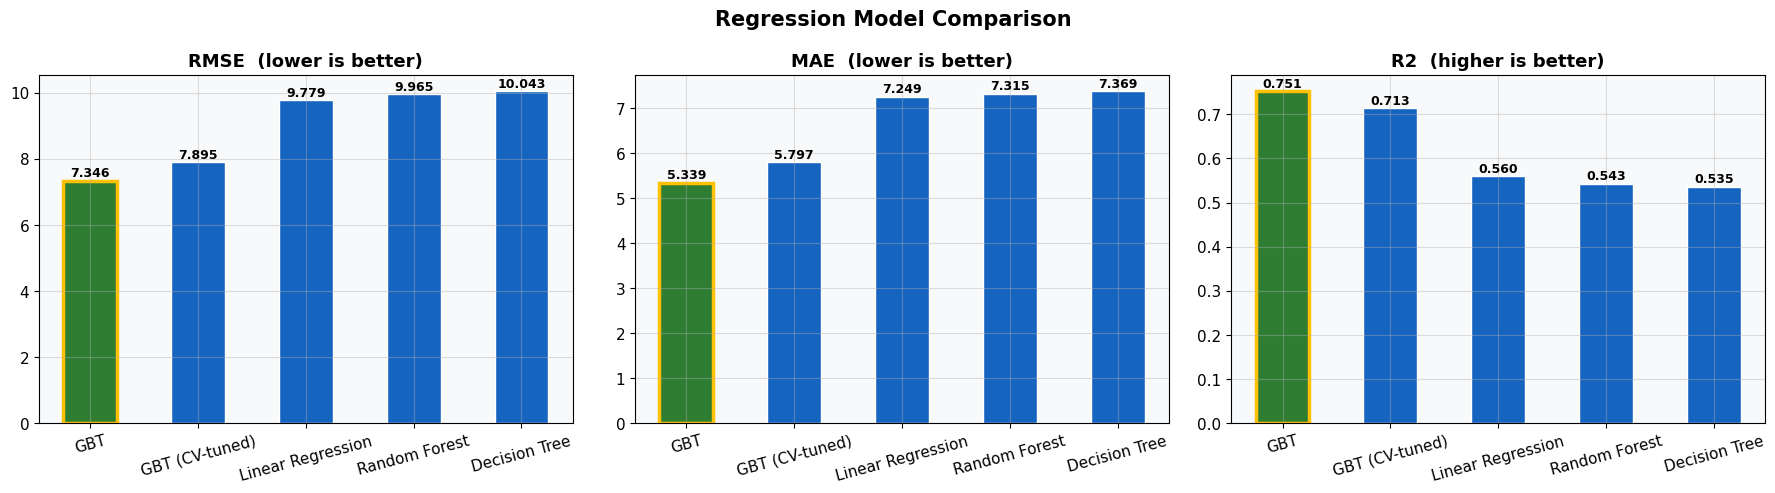

In [54]:
# VIZ: Regression metric comparison bars
models_r    = reg_df['Model'].tolist()
bar_cols_r  = [PAL[2] if m == BEST_REG else PAL[0] for m in models_r]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regression Model Comparison', fontsize=15, fontweight='bold')

for ax, metric, title in zip(
    axes,
    ['RMSE','MAE','R2'],
    ['RMSE  (lower is better)','MAE  (lower is better)','R2  (higher is better)'],
):
    vals = reg_df[metric].tolist()
    bars = ax.bar(models_r, vals, color=bar_cols_r, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.012,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    # Gold border on the winner bar
    bars[models_r.index(BEST_REG)].set_edgecolor('#FFC107')
    bars[models_r.index(BEST_REG)].set_linewidth(2.5)

plt.tight_layout()
save_fig('viz_16_reg_comparison')
plt.show()

Saved viz_17_residuals.png


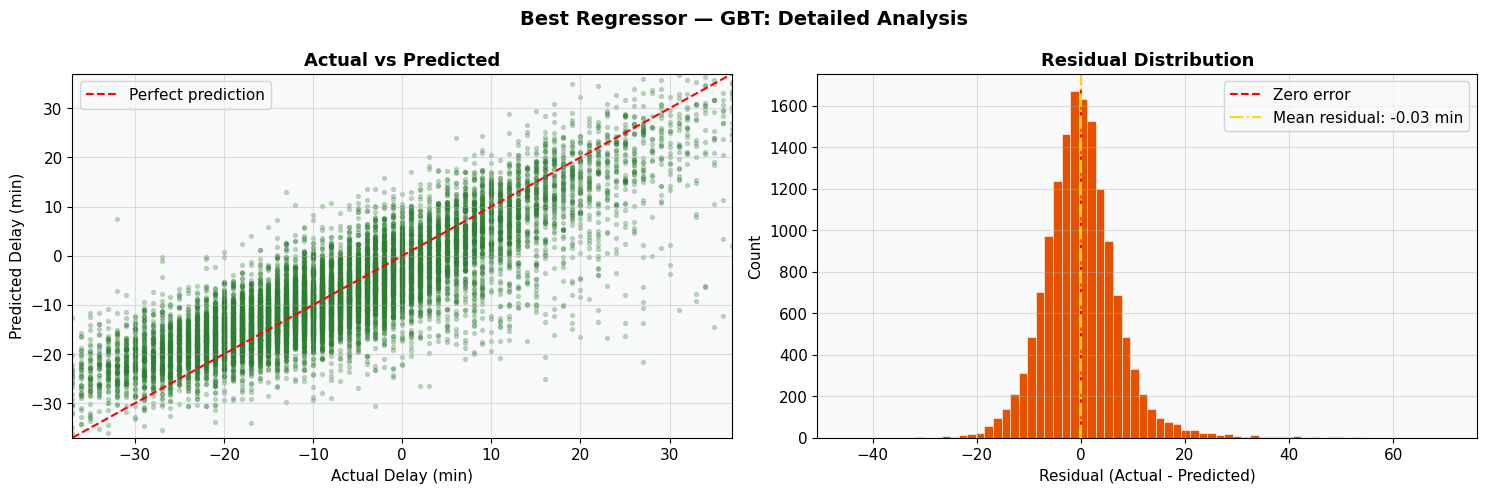

In [55]:
# VIZ: Actual vs predicted + residual plot for best regressor
best_reg_preds = results_reg[BEST_REG].get('preds', None)

# Reconstruct predictions if needed
if best_reg_preds is None:
    model_obj = {
        'Linear Regression': lr,
        'Decision Tree': dt,
        'Random Forest': rf,
        'GBT': gbt,
        'GBT (CV-tuned)': cv_model.bestModel,
    }.get(BEST_REG)
    best_reg_preds = model_obj.transform(test_df) if model_obj else gbt_preds

sp = (
    best_reg_preds.select(LABEL, 'prediction')
    .sample(fraction=min(1.0, 15000/test_df.count()), seed=7)
    .toPandas().dropna()
)
sp['residual'] = sp[LABEL] - sp['prediction']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Best Regressor — {BEST_REG}: Detailed Analysis',
             fontsize=14, fontweight='bold')

lim = max(abs(sp[LABEL].quantile(0.99)), abs(sp['prediction'].quantile(0.99)))
axes[0].scatter(sp[LABEL], sp['prediction'], alpha=0.25, s=8, color=PAL[2])
axes[0].plot([-lim,lim],[-lim,lim], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlim(-lim,lim); axes[0].set_ylim(-lim,lim)
axes[0].set_xlabel('Actual Delay (min)')
axes[0].set_ylabel('Predicted Delay (min)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].hist(sp['residual'], bins=70, color=PAL[3], edgecolor='white', lw=0.4)
axes[1].axvline(0, color='red', lw=1.5, ls='--', label='Zero error')
axes[1].axvline(sp['residual'].mean(), color='gold', lw=1.5, ls='-.',
                label=f'Mean residual: {sp["residual"].mean():.2f} min')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
save_fig('viz_17_residuals')
plt.show()

Saved viz_18_feature_importance.png


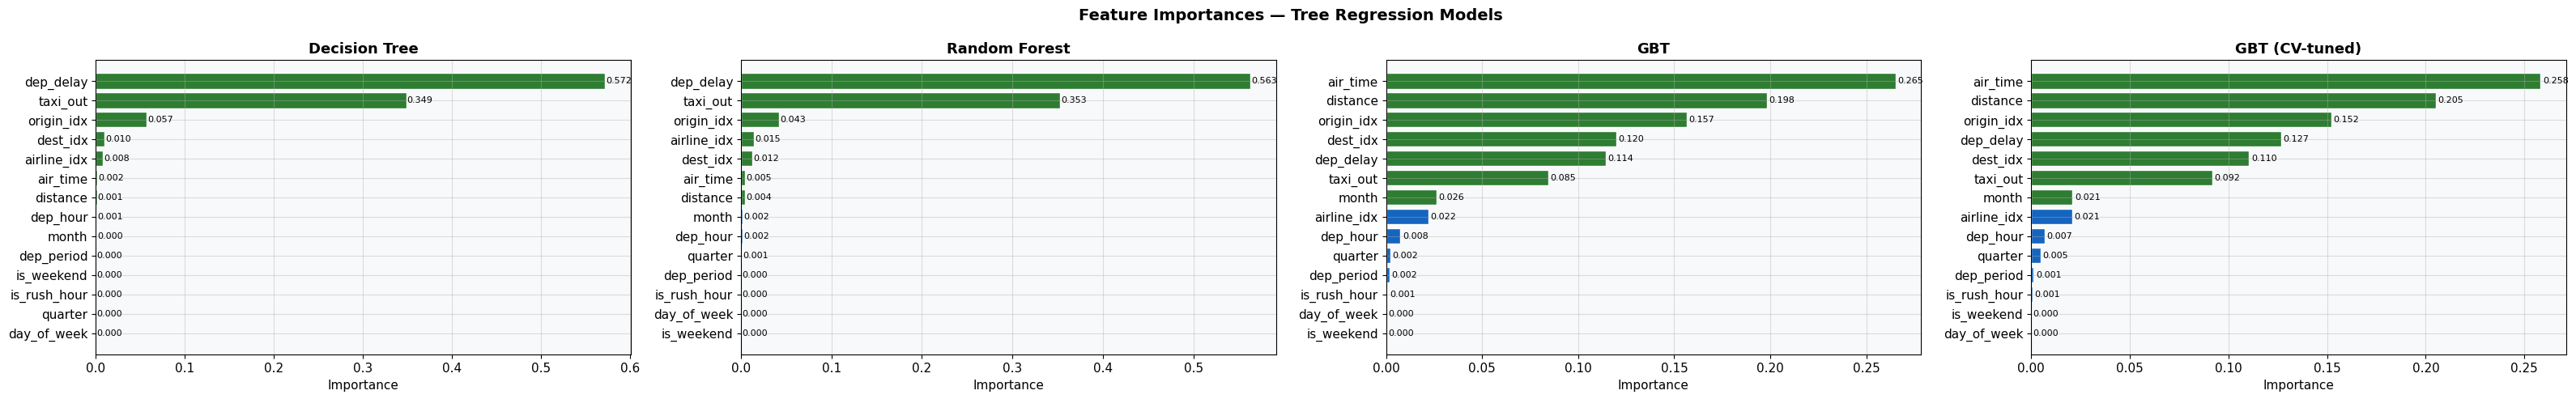

In [56]:
# VIZ: Feature importances for tree-based regression models
tree_regs = {k: v for k, v in results_reg.items() if 'importances' in v}
n_tree = len(tree_regs)
if n_tree > 0:
    fig, axes = plt.subplots(1, n_tree, figsize=(8*n_tree, 5))
    if n_tree == 1: axes = [axes]
    fig.suptitle('Feature Importances — Tree Regression Models',
                 fontsize=14, fontweight='bold')
    for ax, (name, m) in zip(axes, tree_regs.items()):
        imp = pd.DataFrame({
            'feature': FEATURE_COLS,
            'importance': m['importances'].toArray(),
        }).sort_values('importance')
        c_imp = [PAL[0] if v < imp['importance'].median() else PAL[2]
                 for v in imp['importance']]
        ax.barh(imp['feature'], imp['importance'], color=c_imp, edgecolor='white')
        for i, (_, row) in enumerate(imp.iterrows()):
            ax.text(row['importance']+0.001, i,
                    f'{row["importance"]:.3f}', va='center', fontsize=8)
        ax.set_xlabel('Importance')
        ax.set_title(name)
    plt.tight_layout()
    save_fig('viz_18_feature_importance')
    plt.show()

In [ ]:
#Classification comparison table
cls_df = pd.DataFrame([
    {'Model': n,
     'Accuracy': round(m['accuracy']*100,2),
     'Precision': round(m['precision']*100,2),
     'Recall': round(m['recall']*100,2),
     'F1': round(m['f1']*100,2),
     'AUC': round(m['auc'],4),
     'Time (s)': m['time']}
    for n, m in results_cls.items()
]).sort_values('AUC', ascending=False).reset_index(drop=True)
cls_df.insert(0, 'Rank', range(1, len(cls_df)+1))
BEST_CLS = cls_df.iloc[0]['Model']

print('='*78)
print('  CLASSIFICATION RESULTS  —  Higher AUC/F1 is better')
print('='*78)
print(cls_df.to_string(index=False))
print('='*78)
print(f'  Winner : {BEST_CLS}')

  CLASSIFICATION RESULTS  —  Higher AUC/F1 is better
 Rank               Model  Accuracy  Precision  Recall    F1    AUC  Time (s)
    1      GBT Classifier     95.83      95.46   95.83 95.46 0.9503     782.6
    2       Random Forest     95.00      94.39   95.00 94.30 0.9272     409.2
    3 Logistic Regression     93.32      93.60   93.32 90.47 0.9127      27.8
  Winner : GBT Classifier


Saved viz_19_cls_comparison.png


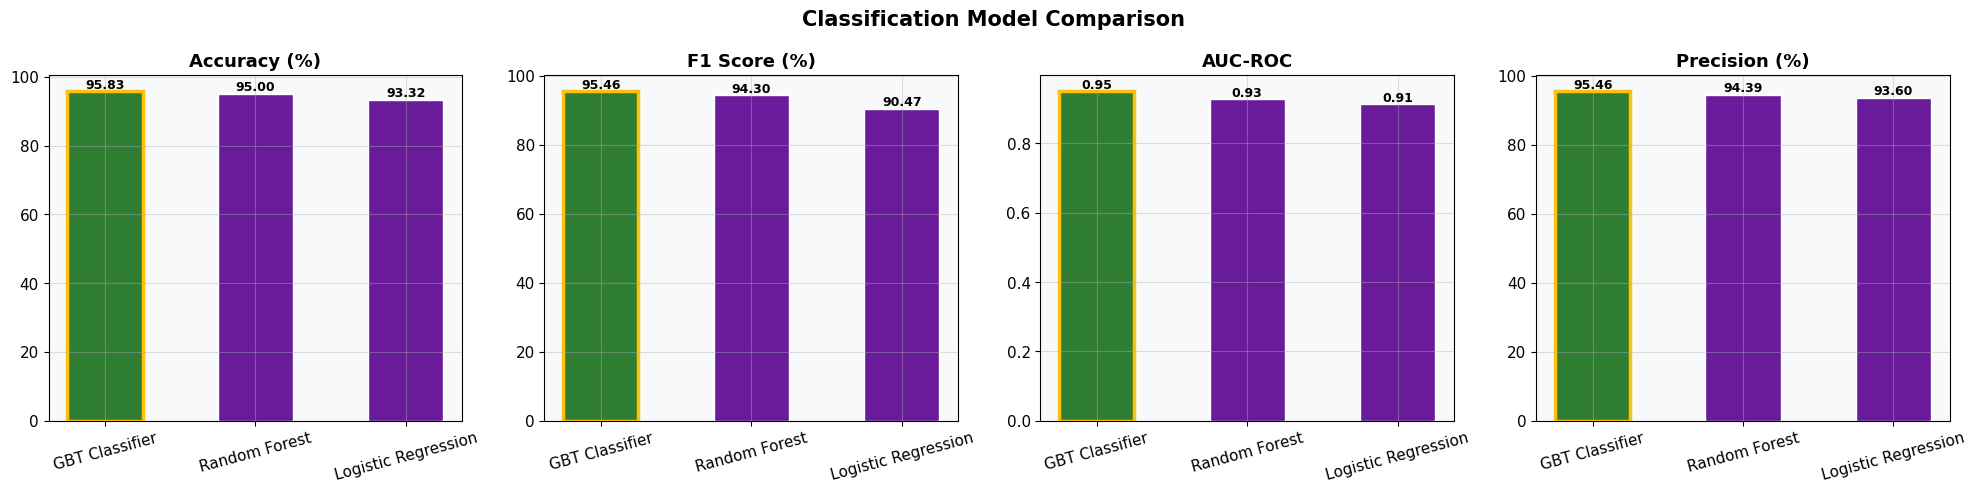

In [58]:
# VIZ: Classification metric comparison bars
models_c   = cls_df['Model'].tolist()
bar_cols_c = [PAL[2] if m == BEST_CLS else PAL[4] for m in models_c]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Classification Model Comparison', fontsize=15, fontweight='bold')

for ax, metric, title in zip(
    axes,
    ['Accuracy','F1','AUC','Precision'],
    ['Accuracy (%)','F1 Score (%)','AUC-ROC','Precision (%)'],
):
    vals = cls_df[metric].tolist()
    bars = ax.bar(models_c, vals, color=bar_cols_c, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    bars[models_c.index(BEST_CLS)].set_edgecolor('#FFC107')
    bars[models_c.index(BEST_CLS)].set_linewidth(2.5)

plt.tight_layout()
save_fig('viz_19_cls_comparison')
plt.show()

---
## Section 10 — Conclusion

In [59]:
best_rmse = results_reg[BEST_REG]['rmse']
best_r2   = results_reg[BEST_REG]['r2']
best_auc  = results_cls[BEST_CLS]['auc']
best_f1   = results_cls[BEST_CLS]['f1']

print('=' * 70)
print('  US FLIGHT DELAY PREDICTOR — FINAL SUMMARY')
print('=' * 70)
print(f'  Dataset        : US Domestic Flights 2018-2022')
print(f'  Total rows     : {TOTAL:,}')
print(f'  Feature count  : {len(FEATURE_COLS)}')
print()
print('  REGRESSION  (predict exact delay in minutes)')
print('  ' + '-'*55)
for _, row in reg_df.iterrows():
    tag = '  <- WINNER' if row['Model'] == BEST_REG else ''
    print(f"  {int(row['Rank'])}. {row['Model']:<25}"
          f"  RMSE={row['RMSE']:.2f}  MAE={row['MAE']:.2f}  R2={row['R2']:.3f}{tag}")
print()
print('  CLASSIFICATION  (predict delayed > 15 min?)')
print('  ' + '-'*55)
for _, row in cls_df.iterrows():
    tag = '  <- WINNER' if row['Model'] == BEST_CLS else ''
    print(f"  {int(row['Rank'])}. {row['Model']:<25}"
          f"  Acc={row['Accuracy']:.1f}%  F1={row['F1']:.1f}%  AUC={row['AUC']:.4f}{tag}")
print()
print(f'  Regression winner  : {BEST_REG}')
print(f'   -> RMSE = {best_rmse:.2f} min, R2 = {best_r2:.3f}')
print(f'   -> The model explains {best_r2*100:.1f}% of the variance in arrival delay')
print()
print(f'  Classification winner : {BEST_CLS}')
print(f'   -> AUC = {best_auc:.4f}, F1 = {best_f1:.4f}')
print('=' * 70)

# Release all caches
train_df.unpersist()
test_df.unpersist()
train_cls.unpersist()
test_cls.unpersist()
df.unpersist()
print('Spark caches released')

  US FLIGHT DELAY PREDICTOR — FINAL SUMMARY
  Dataset        : US Domestic Flights 2018-2022
  Total rows     : 25,160,920
  Feature count  : 14

  REGRESSION  (predict exact delay in minutes)
  -------------------------------------------------------
  1. GBT                        RMSE=7.35  MAE=5.34  R2=0.751  <- WINNER
  2. GBT (CV-tuned)             RMSE=7.89  MAE=5.80  R2=0.713
  3. Linear Regression          RMSE=9.78  MAE=7.25  R2=0.560
  4. Random Forest              RMSE=9.96  MAE=7.32  R2=0.543
  5. Decision Tree              RMSE=10.04  MAE=7.37  R2=0.535

  CLASSIFICATION  (predict delayed > 15 min?)
  -------------------------------------------------------
  1. GBT Classifier             Acc=95.8%  F1=95.5%  AUC=0.9503  <- WINNER
  2. Random Forest              Acc=95.0%  F1=94.3%  AUC=0.9272
  3. Logistic Regression        Acc=93.3%  F1=90.5%  AUC=0.9127

  Regression winner  : GBT
   -> RMSE = 7.35 min, R2 = 0.751
   -> The model explains 75.1% of the variance in arrival